# Ensemble Error Analysis
Deep-dive into FP / FN / TP patterns across `od_only`, `seg_only`, `or`, `and` strategies.

**Pre-requisite:** Run `testing_ensemble.ipynb` first so that
`results_by_strategy_iou`, `od_raw`, `seg_raw`, `od_root`, `val_df`, `data_df`
are in memory — or run Section 0 below to reload everything from scratch.

In [2]:
from ultralytics import YOLO
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import random
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

---
## Section 0 — Re-load (skip if already in memory)

OD  model: 2026_03_11(1)
Seg model: 2026_03_12(1)
Total images: 1444
Using device: 0


Seg Inference: 100%|██████████| 46/46 [00:14<00:00,  3.09it/s]


OD  inference done: 1444 images
Seg inference done: 1444 images


Matching: 100%|██████████| 11/11 [00:17<00:00,  1.63s/it]



IoU threshold = 0.3
  --- OD only ---
  Image-wise   | recall=0.9210  precision=0.9439  F1=0.9267
  Patient-wise | recall=0.9149  precision=0.9695  F1=0.9354
  TP IoU       | n=1402  mean=0.8614  median=0.8830  std=0.0927
  Center dist  | n=1402  mean=3.72  median=2.34  max=91.38
  --- Seg only (bbox) ---
  Image-wise   | recall=0.9178  precision=0.9442  F1=0.9247
  Patient-wise | recall=0.9092  precision=0.9660  F1=0.9302
  TP IoU       | n=1394  mean=0.8593  median=0.8810  std=0.0911
  Center dist  | n=1394  mean=3.86  median=2.33  max=92.99
  --- Fusion OR (union) ---
  Image-wise   | recall=0.9440  precision=0.9635  F1=0.9480
  Patient-wise | recall=0.9384  precision=0.9739  F1=0.9514
  TP IoU       | n=1441  mean=0.8590  median=0.8821  std=0.0936
  Center dist  | n=1441  mean=3.81  median=2.34  max=91.38
  --- Fusion AND (intersection) ---
  Image-wise   | recall=0.8937  precision=0.9258  F1=0.9041
  Patient-wise | recall=0.8850  precision=0.9677  F1=0.9159
  TP IoU       | n=135

AP  mAP@0.5:0.95  img_recall  \
strategy                  iou_threshold                                     
OD only                   0.3            0.8898        0.6512      0.9210   
                          0.5            0.8669        0.6512      0.9099   
                          0.7            0.8299        0.6512      0.8761   
Seg only (bbox)           0.3            0.8783        0.6439      0.9178   
                          0.5            0.8653        0.6439      0.9094   
                          0.7            0.8253        0.6439      0.8748   
Fusion OR (union)         0.3            0.9085        0.6668      0.9440   
                          0.5            0.8952        0.6668      0.9339   
                          0.7            0.8479        0.6668      0.8956   
Fusion AND (intersection) 0.3            0.8606        0.6413      0.8937   
                          0.5            0.8474        0.6413      0.8844   
                          0.7            0.8108        0.6413      0.8585   

                                         img_precision  img_f1  pat_recall  \
strategy                  iou_threshold                                      
OD only                   0.3                   0.9439  0.9267      0.9149   
                          0.5                   0.9317  0.9153      0.9074   
                          0.7                   0.8960  0.8811      0.8758   
Seg only (bbox)           0.3                   0.9442  0.9247      0.9092   
                          0.5                   0.9356  0.9164      0.9039   
                          0.7                   0.8995  0.8812      0.8721   
Fusion OR (union)         0.3                   0.9635  0.9480      0.9384   
                          0.5                   0.9528  0.9377      0.9312   
                          0.7                   0.9133  0.8992      0.8973   
Fusion AND (intersection) 0.3                   0.9258  0.9041      0.8850   
                          0.5                   0.9161  0.8946      0.8797   
                          0.7                   0.8874  0.8677      0.8565   

                                         pat_precision  pat_f1  iou_mean  \
strategy                  iou_threshold                                    
OD only                   0.3                   0.9695  0.9354    0.8614   
                          0.5                   0.9603  0.9274    0.8675   
                          0.7                   0.9251  0.8943    0.8770   
Seg only (bbox)           0.3                   0.9660  0.9302    0.8593   
                          0.5                   0.9586  0.9241    0.8647   
                          0.7                   0.9227  0.8906    0.8737   
Fusion OR (union)         0.3                   0.9739  0.9514    0.8590   
                          0.5                   0.9654  0.9438    0.8651   
                          0.7                   0.9267  0.9080    0.8752   
Fusion AND (intersection) 0.3                   0.9677  0.9159    0.8670   
                          0.5                   0.9590  0.9097    0.8719   
                          0.7                   0.9308  0.8846    0.8792   

                                         iou_median  cd_mean  cd_median  \
strategy                  iou_threshold                                   
OD only                   0.3                0.8830     3.72       2.34   
                          0.5                0.8839     3.30       2.32   
                          0.7                0.8877     3.00       2.28   
Seg only (bbox)           0.3                0.8810     3.86       2.33   
                          0.5                0.8819     3.40       2.32   
                          0.7                0.8855     3.10       2.28   
Fusion OR (union)         0.3                0.8821     3.81       2.34   
                          0.5                0.8838     3.40       2.33   
                          0.7                0.8871     3.

Saved to /datadrive/yolo_output/ensemble_2026_03_11(1)__2026_03_12(1)/ensemble_metrics.csv


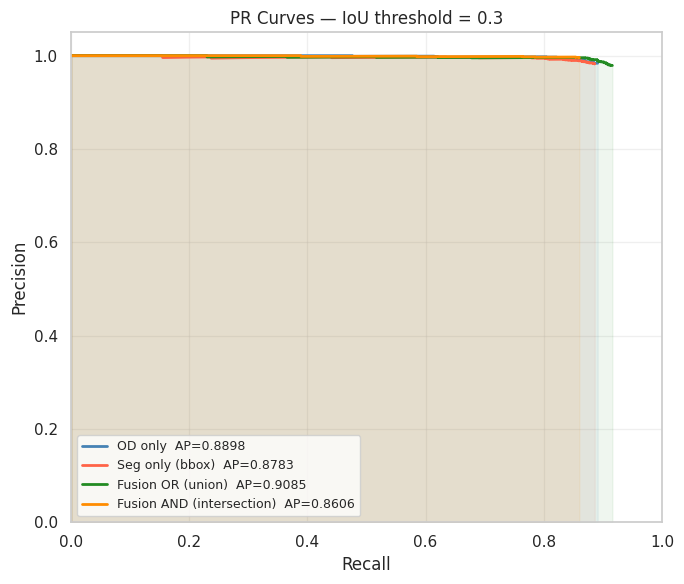

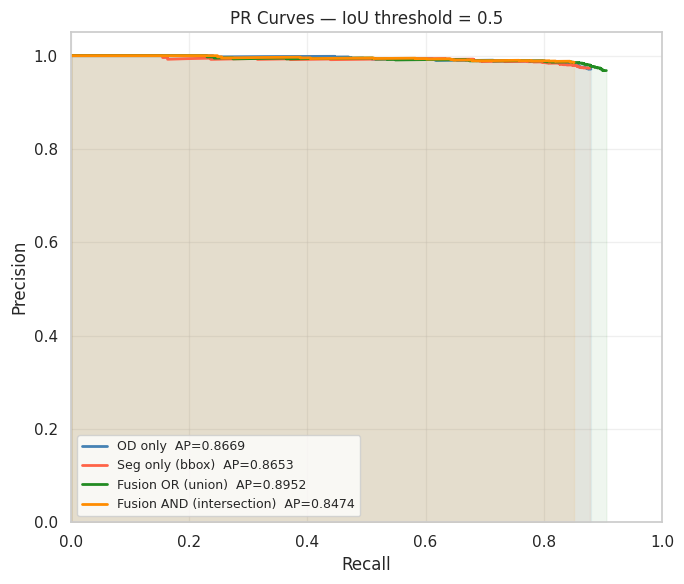

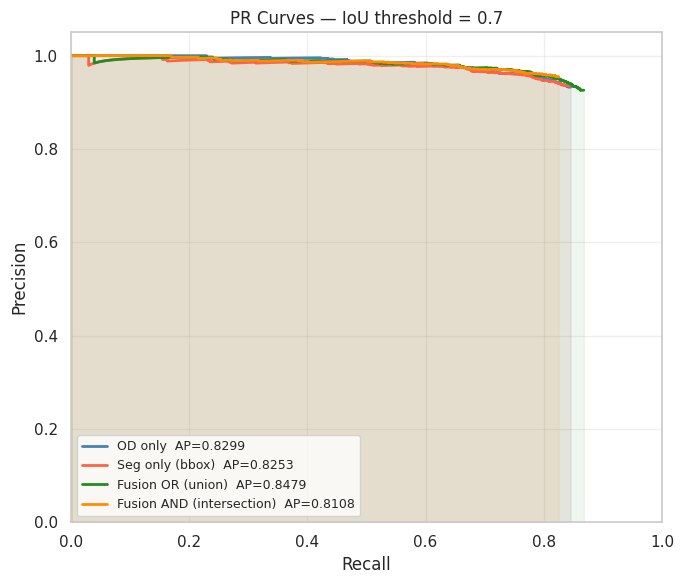

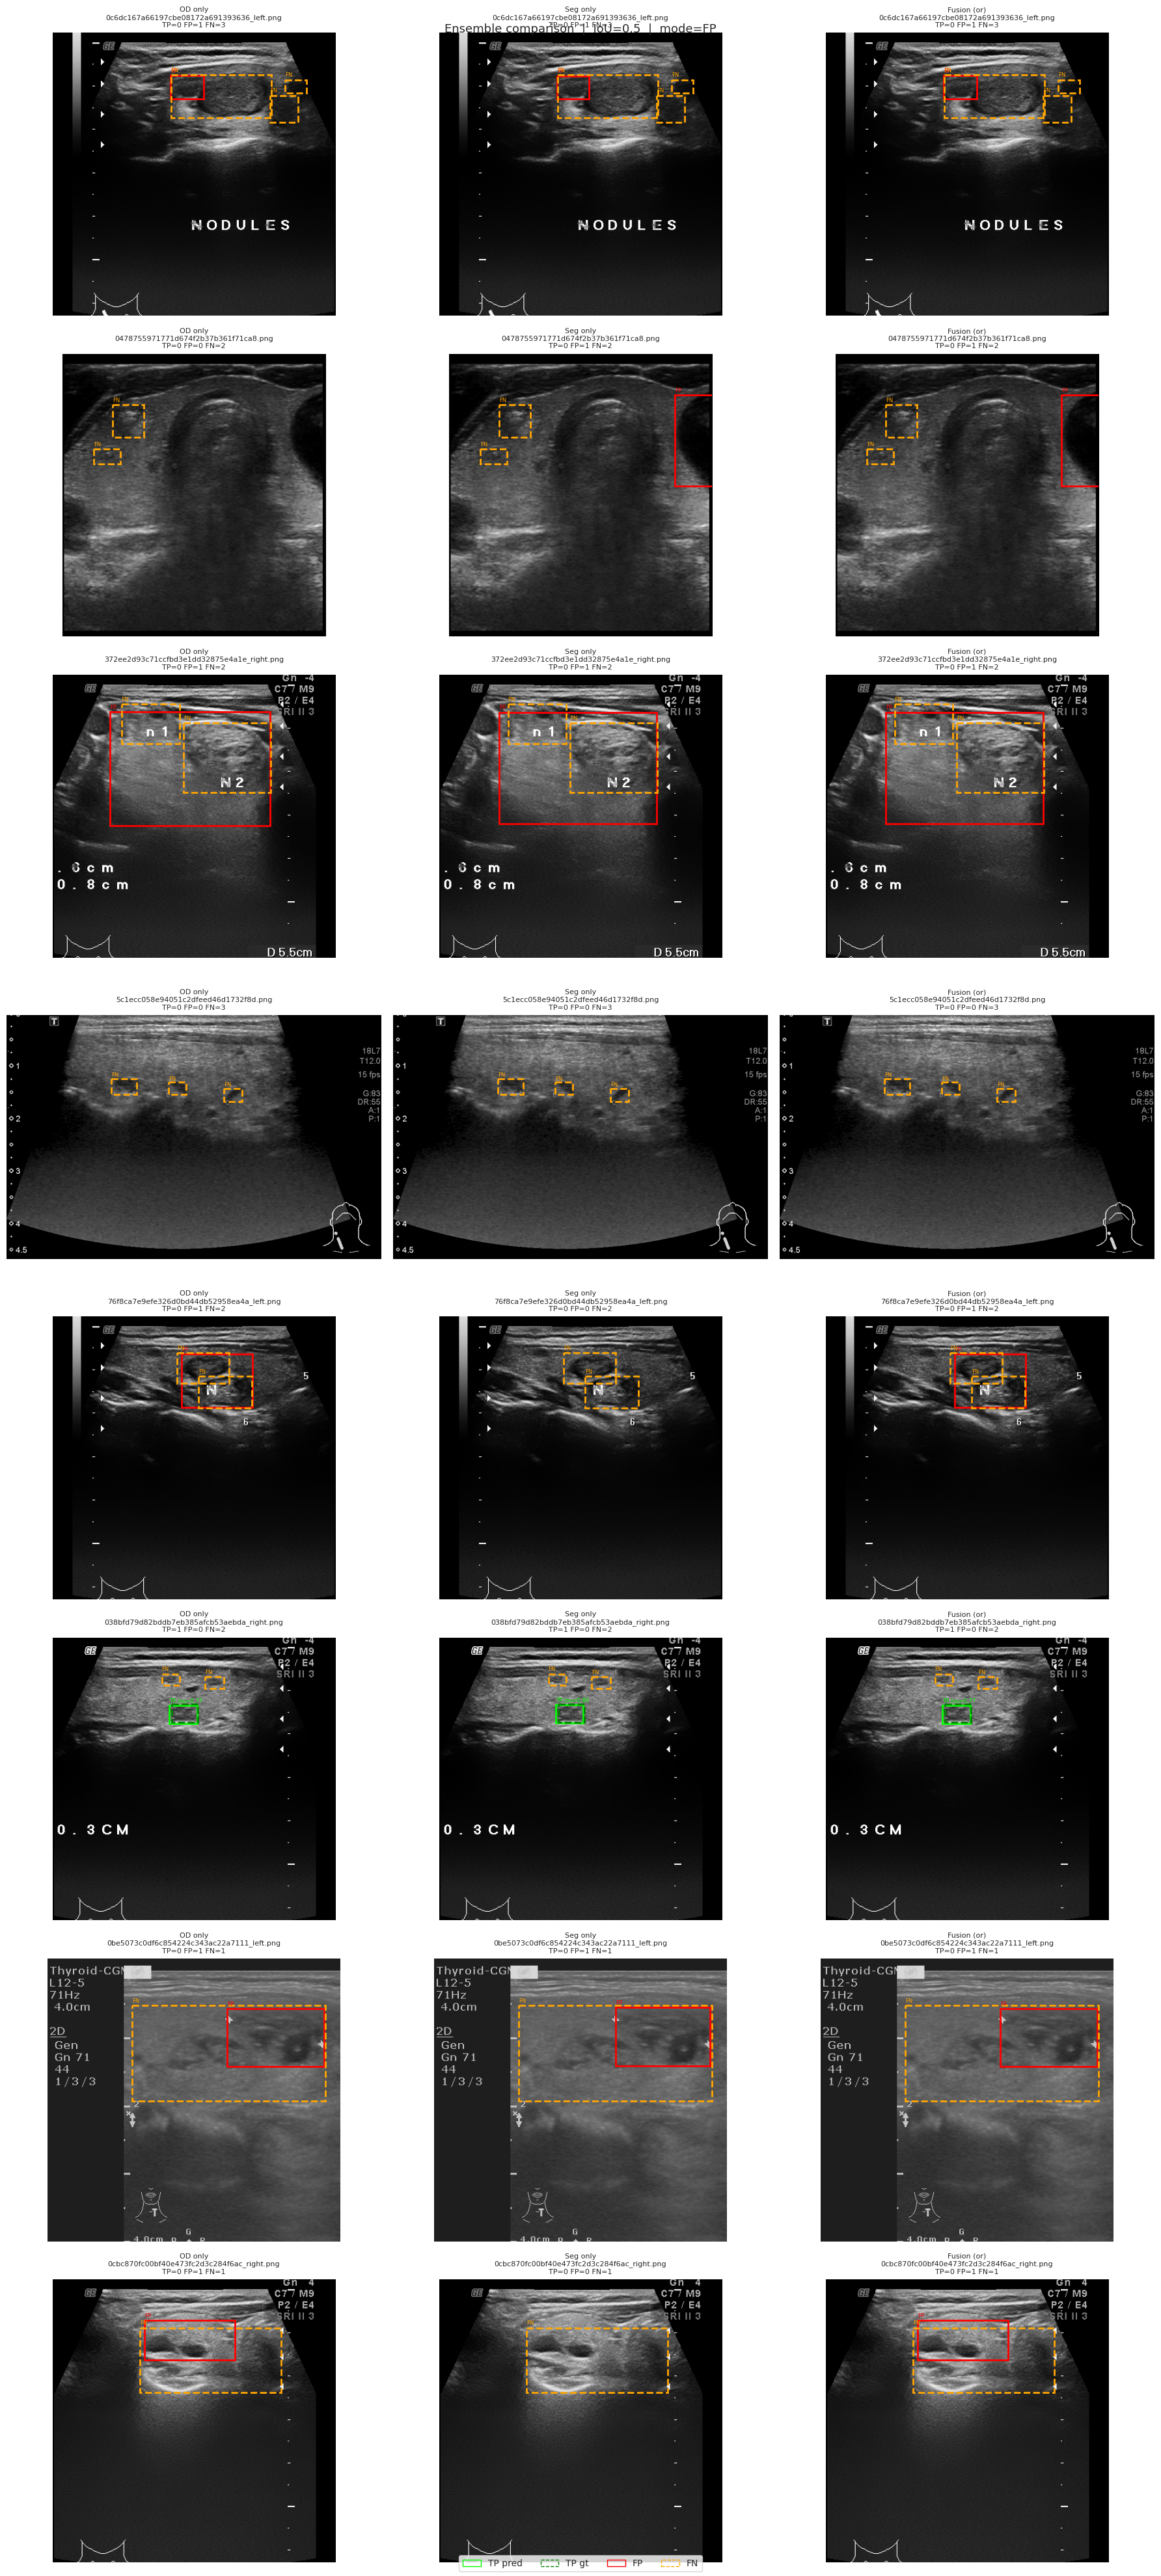

Ready.


In [6]:
# ── Copy all helper functions from testing_ensemble.ipynb ────────────────────
# (Paste or %run the notebook, or uncomment the line below)
%run testing_ensemble.ipynb

# ── If already in memory just verify ─────────────────────────────────────────
assert 'results_by_strategy_iou' in dir(), \
    "Run testing_ensemble.ipynb first, or uncomment %run above."

strategies = ['od_only', 'seg_only', 'or', 'and']
strategy_labels = {
    'od_only':  'OD only',
    'seg_only': 'Seg only',
    'or':       'Fusion OR',
    'and':      'Fusion AND',
}
COLORS = {
    'od_only':  '#4878CF',
    'seg_only': '#D65F5F',
    'or':       '#6ACC65',
    'and':      '#E48C2A',
}
IOU_ANALYSIS = 0.5          # primary IoU threshold for error analysis
print('Ready.')

---
## Section 1 — Overall Error Distribution

,TP,FP,FN,TN,recall,precision,f1
strategy,,,,,,,
OD only,1384,41,189,1,0.8798,0.9712,0.9233
Seg only,1381,38,192,1,0.8779,0.9732,0.9231
Fusion OR,1425,47,148,1,0.9059,0.9681,0.9360
Fusion AND,1339,20,234,1,0.8512,0.9853,0.9134


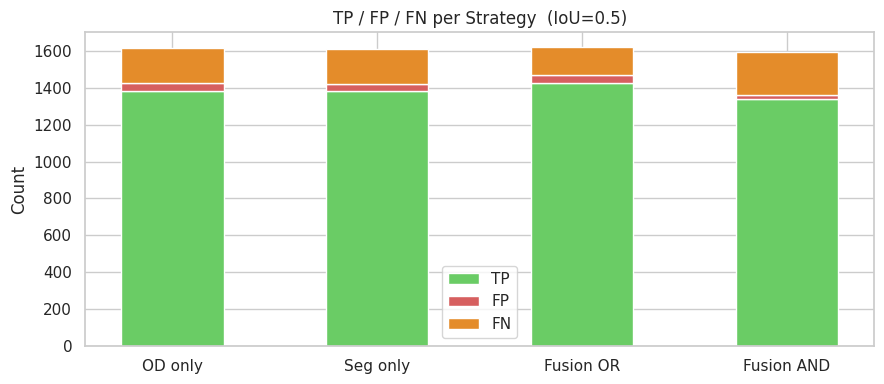

In [7]:
# ── Count TP / FP / FN / TN per strategy at IOU_ANALYSIS ─────────────────────
count_rows = []
for s in strategies:
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    vc = df['match_type'].value_counts()
    tp = vc.get('TP', 0)
    fp = vc.get('FP', 0)
    fn = vc.get('FN', 0)
    tn = vc.get('TN', 0)
    total_gt = tp + fn
    count_rows.append(dict(
        strategy=strategy_labels[s],
        TP=tp, FP=fp, FN=fn, TN=tn,
        recall  =round(tp/(tp+fn+1e-9),4),
        precision=round(tp/(tp+fp+1e-9),4),
        f1      =round(2*tp/(2*tp+fp+fn+1e-9),4),
    ))

count_df = pd.DataFrame(count_rows).set_index('strategy')
display(count_df)

# ── Stacked bar ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(strategies))
w = 0.5
tp_vals = count_df['TP'].values
fp_vals = count_df['FP'].values
fn_vals = count_df['FN'].values
ax.bar(x, tp_vals, w, label='TP', color='#6ACC65')
ax.bar(x, fp_vals, w, bottom=tp_vals, label='FP', color='#D65F5F')
ax.bar(x, fn_vals, w, bottom=tp_vals+fp_vals, label='FN', color='#E48C2A')
ax.set_xticks(x)
ax.set_xticklabels([strategy_labels[s] for s in strategies])
ax.set_ylabel('Count')
ax.set_title(f'TP / FP / FN per Strategy  (IoU={IOU_ANALYSIS})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2 — FP Analysis

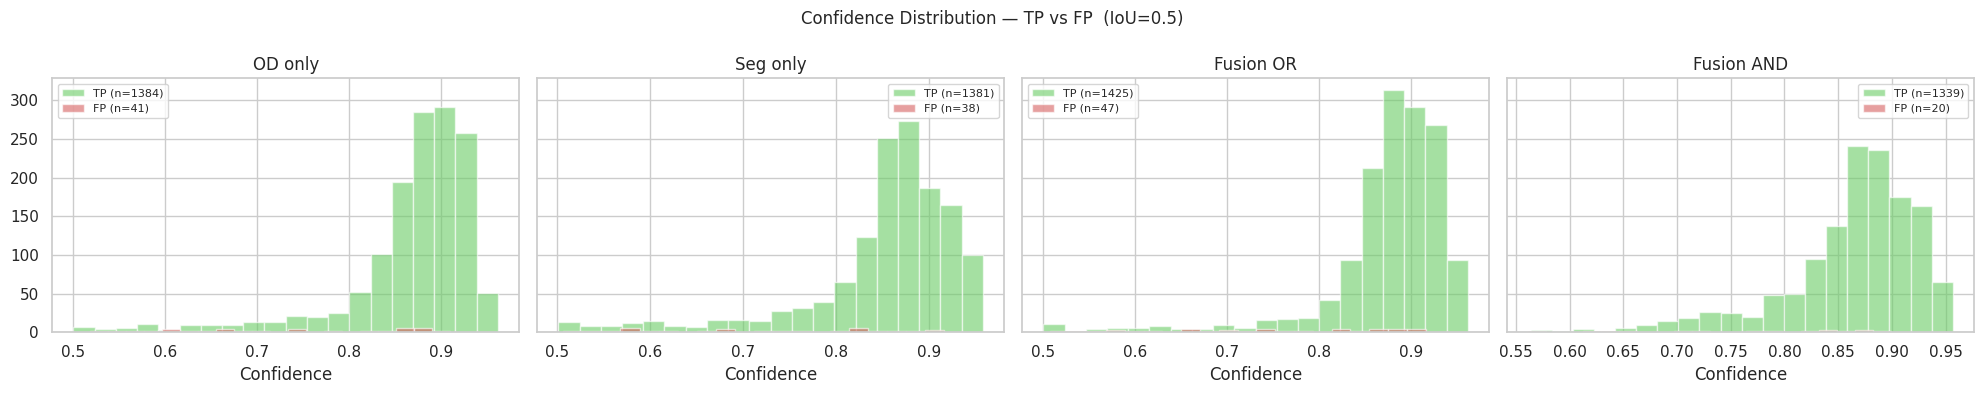

In [8]:
# ── 2a. FP Confidence Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, len(strategies), figsize=(5*len(strategies), 4), sharey=True)
for ax, s in zip(axes, strategies):
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    fp_conf = df.loc[df['match_type']=='FP', 'conf'].dropna()
    tp_conf = df.loc[df['match_type']=='TP', 'conf'].dropna()
    ax.hist(tp_conf, bins=20, alpha=0.6, color='#6ACC65', label=f'TP (n={len(tp_conf)})')
    ax.hist(fp_conf, bins=20, alpha=0.6, color='#D65F5F', label=f'FP (n={len(fp_conf)})')
    ax.set_title(strategy_labels[s])
    ax.set_xlabel('Confidence')
    ax.legend(fontsize=8)
fig.suptitle(f'Confidence Distribution — TP vs FP  (IoU={IOU_ANALYSIS})', fontsize=12)
plt.tight_layout()
plt.show()

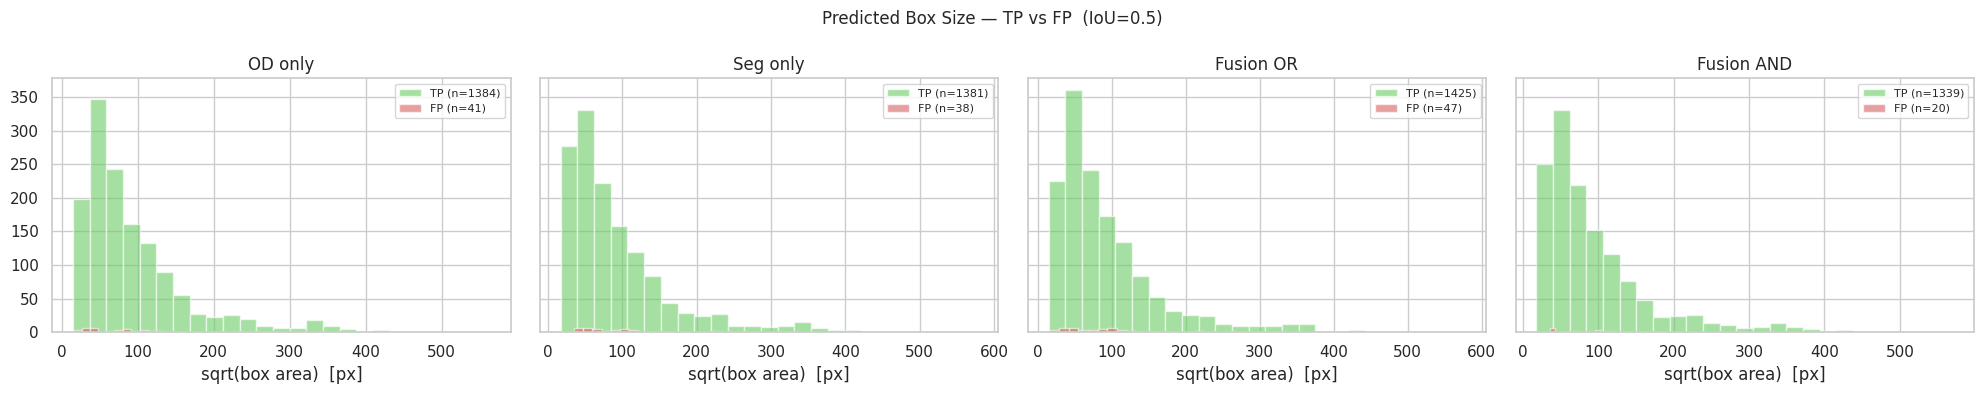

In [9]:
# ── 2b. FP Box Area Distribution ─────────────────────────────────────────────
def box_area(box):
    if box is None:
        return None
    return (box[2]-box[0]) * (box[3]-box[1])

fig, axes = plt.subplots(1, len(strategies), figsize=(5*len(strategies), 4), sharey=True)
for ax, s in zip(axes, strategies):
    df = results_by_strategy_iou[s][IOU_ANALYSIS].copy()
    df['pred_area'] = df['pred_box'].apply(box_area)
    fp_area = df.loc[df['match_type']=='FP', 'pred_area'].dropna()
    tp_area = df.loc[df['match_type']=='TP', 'pred_area'].dropna()
    ax.hist(np.sqrt(tp_area.clip(0)), bins=25, alpha=0.6, color='#6ACC65',
            label=f'TP (n={len(tp_area)})')
    ax.hist(np.sqrt(fp_area.clip(0)), bins=25, alpha=0.6, color='#D65F5F',
            label=f'FP (n={len(fp_area)})')
    ax.set_title(strategy_labels[s])
    ax.set_xlabel('sqrt(box area)  [px]')
    ax.legend(fontsize=8)
fig.suptitle(f'Predicted Box Size — TP vs FP  (IoU={IOU_ANALYSIS})', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# ── 2c. FP Source (only relevant for fusion strategies) ───────────────────────
for s in ['or', 'and']:
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    fp_src = df.loc[df['match_type']=='FP', 'source'].value_counts()
    print(f"\nFP source breakdown [{strategy_labels[s]}]")
    print(fp_src.to_string())


FP source breakdown [Fusion OR]
source
od     27
seg    20

FP source breakdown [Fusion AND]
source
both    20


---
## Section 3 — FN Analysis (Missed Nodules)

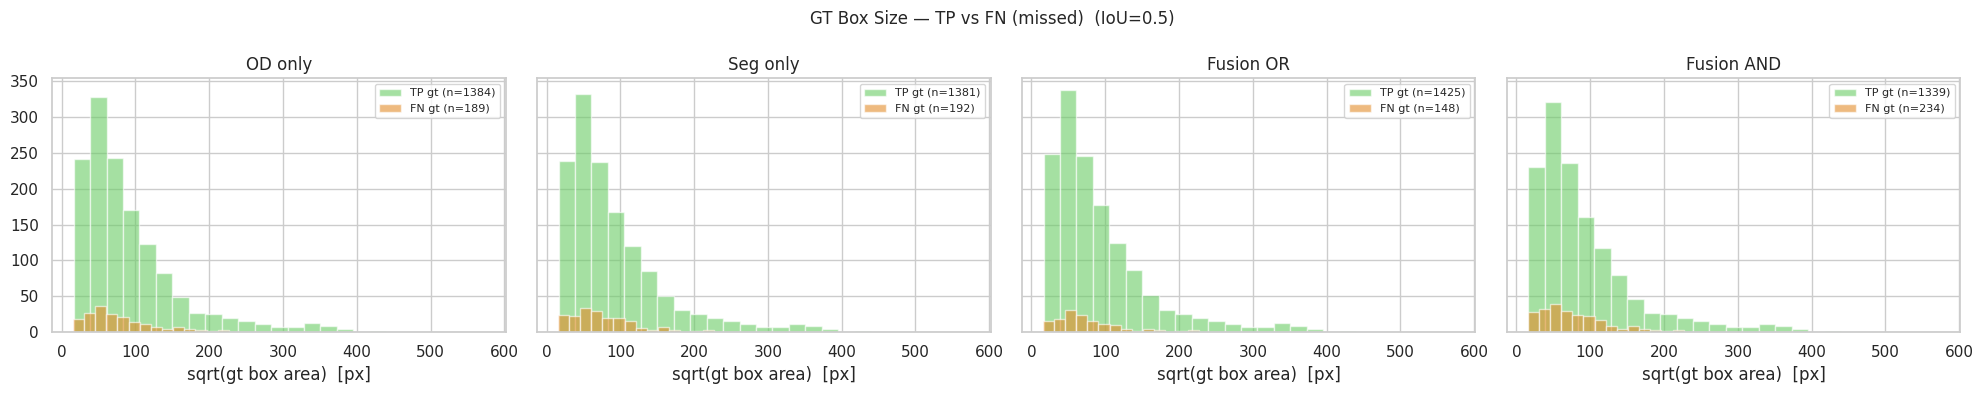

In [11]:
# ── 3a. FN GT Box Area Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(strategies), figsize=(5*len(strategies), 4), sharey=True)
for ax, s in zip(axes, strategies):
    df = results_by_strategy_iou[s][IOU_ANALYSIS].copy()
    df['gt_area'] = df['gt_box'].apply(box_area)
    fn_area = df.loc[df['match_type']=='FN', 'gt_area'].dropna()
    tp_area = df.loc[df['match_type']=='TP', 'gt_area'].dropna()
    ax.hist(np.sqrt(tp_area.clip(0)), bins=25, alpha=0.6, color='#6ACC65',
            label=f'TP gt (n={len(tp_area)})')
    ax.hist(np.sqrt(fn_area.clip(0)), bins=25, alpha=0.6, color='#E48C2A',
            label=f'FN gt (n={len(fn_area)})')
    ax.set_title(strategy_labels[s])
    ax.set_xlabel('sqrt(gt box area)  [px]')
    ax.legend(fontsize=8)
fig.suptitle(f'GT Box Size — TP vs FN (missed)  (IoU={IOU_ANALYSIS})', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ── 3b. FN size quartile breakdown ───────────────────────────────────────────
# Use OD-only as reference for GT sizes, then count FN by size bin
ref_df = results_by_strategy_iou['od_only'][IOU_ANALYSIS].copy()
ref_df['gt_area'] = ref_df['gt_box'].apply(box_area)
ref_df['gt_side']  = np.sqrt(ref_df['gt_area'].clip(0))

# Bin into small / medium / large using TP+FN gt boxes
gt_sizes = ref_df.loc[ref_df['match_type'].isin(['TP','FN']), 'gt_side'].dropna()
q33, q66 = gt_sizes.quantile([0.33, 0.66])

def size_bin(v):
    if pd.isna(v):   return 'unknown'
    if v < q33:      return 'small'
    if v < q66:      return 'medium'
    return 'large'

print(f'Size bins  small:<{q33:.1f}px  medium:<{q66:.1f}px  large:>={q66:.1f}px\n')

rows = []
for s in strategies:
    df = results_by_strategy_iou[s][IOU_ANALYSIS].copy()
    df['gt_area'] = df['gt_box'].apply(box_area)
    df['gt_side']  = np.sqrt(df['gt_area'].clip(0))
    df['size_bin'] = df['gt_side'].apply(size_bin)
    for sz in ['small','medium','large']:
        sub = df[df['size_bin']==sz]
        tp = (sub['match_type']=='TP').sum()
        fn = (sub['match_type']=='FN').sum()
        rows.append(dict(strategy=strategy_labels[s], size=sz,
                         TP=tp, FN=fn,
                         recall=round(tp/(tp+fn+1e-9),4)))

sz_df = pd.DataFrame(rows)
pivot  = sz_df.pivot_table(index='size', columns='strategy', values='recall')
pivot  = pivot.reindex(['small','medium','large'])
display(pivot.style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=None))

Size bins  small:<51.8px  medium:<95.4px  large:>=95.4px



strategy,Fusion AND,Fusion OR,OD only,Seg only
size,,,,
small,0.848,0.909,0.880,0.880
medium,0.838,0.877,0.861,0.852
large,0.867,0.931,0.897,0.901


---
## Section 4 — Agreement / Disagreement Between OD and Seg

In [13]:
# For each image compare OD-only and Seg-only at IOU_ANALYSIS
od_df  = results_by_strategy_iou['od_only'][IOU_ANALYSIS]
seg_df = results_by_strategy_iou['seg_only'][IOU_ANALYSIS]

def per_image_counts(df, mt):
    return df[df['match_type']==mt].groupby('file_name').size()

od_tp  = per_image_counts(od_df,  'TP').rename('od_tp')
od_fp  = per_image_counts(od_df,  'FP').rename('od_fp')
od_fn  = per_image_counts(od_df,  'FN').rename('od_fn')
seg_tp = per_image_counts(seg_df, 'TP').rename('seg_tp')
seg_fp = per_image_counts(seg_df, 'FP').rename('seg_fp')
seg_fn = per_image_counts(seg_df, 'FN').rename('seg_fn')

all_fnames = set(od_df['file_name'].unique()) | set(seg_df['file_name'].unique())
agr_df = pd.DataFrame(index=sorted(all_fnames))
for ser in [od_tp, od_fp, od_fn, seg_tp, seg_fp, seg_fn]:
    agr_df = agr_df.join(ser, how='left')
agr_df = agr_df.fillna(0).astype(int)

# Cases where both models produce FP (likely hard region)
agr_df['both_fp'] = ((agr_df['od_fp']>0) & (agr_df['seg_fp']>0)).astype(int)
# Cases where both models miss the nodule
agr_df['both_fn'] = ((agr_df['od_fn']>0) & (agr_df['seg_fn']>0)).astype(int)
# Only OD fails
agr_df['only_od_fn']  = ((agr_df['od_fn']>0) & (agr_df['seg_fn']==0)).astype(int)
# Only Seg fails
agr_df['only_seg_fn'] = ((agr_df['seg_fn']>0) & (agr_df['od_fn']==0)).astype(int)

print('Image-level agreement summary (FP / FN):')
summary = {
    'Images with FP in BOTH models': agr_df['both_fp'].sum(),
    'Images with FN in BOTH models': agr_df['both_fn'].sum(),
    'Images with FN only in OD':     agr_df['only_od_fn'].sum(),
    'Images with FN only in Seg':    agr_df['only_seg_fn'].sum(),
}
for k, v in summary.items():
    print(f'  {k}: {v}')

Image-level agreement summary (FP / FN):
  Images with FP in BOTH models: 18
  Images with FN in BOTH models: 132
  Images with FN only in OD: 35
  Images with FN only in Seg: 42


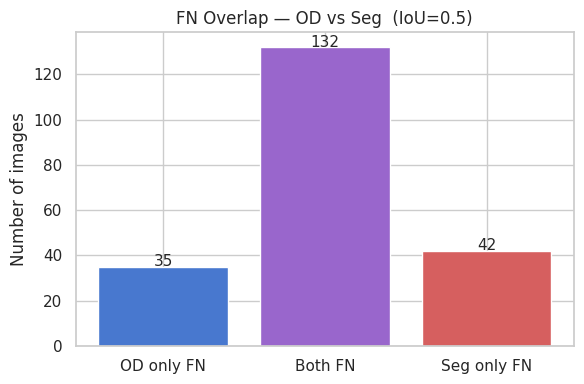

In [14]:
# ── Venn-style bar: unique & shared FN counts ─────────────────────────────────
vals = [
    agr_df['only_od_fn'].sum(),
    agr_df['both_fn'].sum(),
    agr_df['only_seg_fn'].sum(),
]
labels = ['OD only FN', 'Both FN', 'Seg only FN']
colors_v = ['#4878CF', '#9966CC', '#D65F5F']
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, vals, color=colors_v, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v),
            ha='center', fontsize=11)
ax.set_ylabel('Number of images')
ax.set_title(f'FN Overlap — OD vs Seg  (IoU={IOU_ANALYSIS})')
plt.tight_layout()
plt.show()

---
## Section 5 — OR vs AND Strategy: What Each Strategy Gains / Loses

In [15]:
or_df  = results_by_strategy_iou['or'][IOU_ANALYSIS]
and_df = results_by_strategy_iou['and'][IOU_ANALYSIS]

def image_error_set(df, mt):
    return set(df[df['match_type']==mt]['file_name'].unique())

or_fp_imgs  = image_error_set(or_df,  'FP')
and_fp_imgs = image_error_set(and_df, 'FP')
or_fn_imgs  = image_error_set(or_df,  'FN')
and_fn_imgs = image_error_set(and_df, 'FN')

print('FP images:')
print(f'  OR only  : {len(or_fp_imgs - and_fp_imgs)}')
print(f'  AND only : {len(and_fp_imgs - or_fp_imgs)}')
print(f'  Both     : {len(or_fp_imgs & and_fp_imgs)}')
print('\nFN images:')
print(f'  OR only  : {len(or_fn_imgs - and_fn_imgs)}')
print(f'  AND only : {len(and_fn_imgs - or_fn_imgs)}')
print(f'  Both     : {len(or_fn_imgs & and_fn_imgs)}')

FP images:
  OR only  : 27
  AND only : 1
  Both     : 19

FN images:
  OR only  : 0
  AND only : 78
  Both     : 132


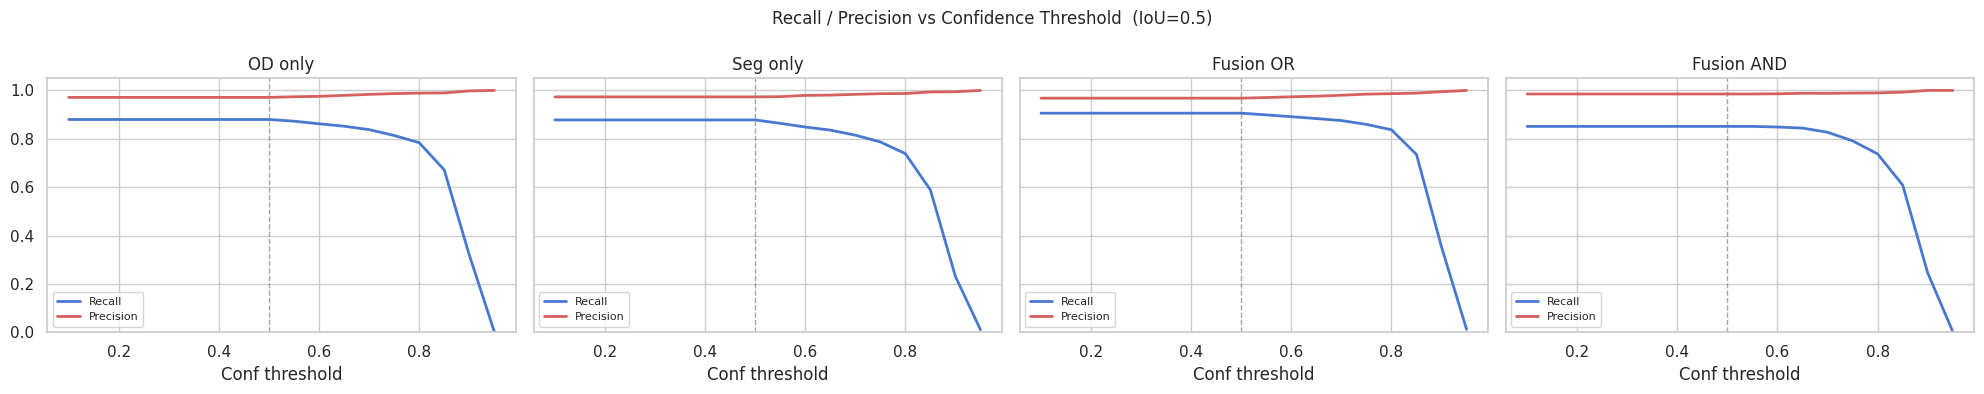

In [16]:
# ── Confidence threshold sweep: recall & precision vs threshold ───────────────
conf_thresholds = np.arange(0.1, 1.0, 0.05)

fig, axes = plt.subplots(1, len(strategies), figsize=(5*len(strategies), 4), sharey=True)

for ax, s in zip(axes, strategies):
    df = results_by_strategy_iou[s][IOU_ANALYSIS].copy()
    recalls, precisions = [], []
    total_gt = df['match_type'].isin(['TP','FN']).sum()
    for thr in conf_thresholds:
        # Apply threshold: FP/TP below threshold become FN (missed)
        mask_pred = df['match_type'].isin(['TP','FP']) & (df['conf'] < thr)
        tp = ((df['match_type']=='TP') & (~mask_pred)).sum()
        fp = ((df['match_type']=='FP') & (~mask_pred)).sum()
        fn = df['match_type'].isin(['FN']).sum() + ((df['match_type']=='TP') & mask_pred).sum()
        recalls.append(tp/(tp+fn+1e-9))
        precisions.append(tp/(tp+fp+1e-9))
    ax.plot(conf_thresholds, recalls,    label='Recall',    color='#4878CF', linewidth=2)
    ax.plot(conf_thresholds, precisions, label='Precision', color='#D65F5F', linewidth=2)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(strategy_labels[s])
    ax.set_xlabel('Conf threshold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

fig.suptitle(f'Recall / Precision vs Confidence Threshold  (IoU={IOU_ANALYSIS})', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 6 — Patient-Level Error Analysis

In [17]:
# ── Top-N worst patients by total errors (FP + FN) ───────────────────────────
TOP_N = 20

def patient_error_df(df):
    g = df.groupby('patient_ID')['match_type'].value_counts().unstack(fill_value=0)
    for c in ['TP','FP','FN']:
        if c not in g: g[c] = 0
    g['total_errors'] = g['FP'] + g['FN']
    g['recall']    = g['TP'] / (g['TP'] + g['FN'] + 1e-9)
    g['precision'] = g['TP'] / (g['TP'] + g['FP'] + 1e-9)
    return g

for s in strategies:
    df  = results_by_strategy_iou[s][IOU_ANALYSIS]
    pat = patient_error_df(df)
    worst = pat.nlargest(TOP_N, 'total_errors')[['TP','FP','FN','total_errors','recall','precision']]
    print(f'\n── {strategy_labels[s]} — Top {TOP_N} worst patients ──')
    display(worst.style.format({'recall':'{:.2f}','precision':'{:.2f}'}))


── OD only — Top 20 worst patients ──


match_type,TP,FP,FN,total_errors,recall,precision
patient_ID,,,,,,
1B233496FD33D99C5C06A2B22C4503796BD343DF,7,3,8,11,0.47,0.70
830FF4983BCF9BDD2496DC86034E522B8A464A68,6,2,8,10,0.43,0.75
7233FBC7D6F54331E7F4B868E09D1981658765B8,2,4,4,8,0.33,0.33
CBD2C2BD4ED704D2C1A7049C298C354329AE03F1,7,1,5,6,0.58,0.87
E5F11C718BD99748D318F2776CB454E3E6FE9E7D,10,0,6,6,0.62,1.00
7AFBA1032B243B56A8D56FF267A3B9358D895B77,11,0,5,5,0.69,1.00
DBFFC4EFC1B552AB35942667D442BE8515DFA2B4,9,1,4,5,0.69,0.90
ECB1E2C250D548B68605338C47E5BFDFDF369029,8,1,4,5,0.67,0.89
F66D80D2AC290289CC69F7EEF40E91CC421F7D16,4,1,4,5,0.50,0.80



── Seg only — Top 20 worst patients ──


match_type,TP,FP,FN,total_errors,recall,precision
patient_ID,,,,,,
1B233496FD33D99C5C06A2B22C4503796BD343DF,8,3,7,10,0.53,0.73
830FF4983BCF9BDD2496DC86034E522B8A464A68,7,2,7,9,0.50,0.78
E5F11C718BD99748D318F2776CB454E3E6FE9E7D,10,1,6,7,0.62,0.91
7233FBC7D6F54331E7F4B868E09D1981658765B8,3,3,3,6,0.50,0.50
CBD2C2BD4ED704D2C1A7049C298C354329AE03F1,7,1,5,6,0.58,0.87
ECB1E2C250D548B68605338C47E5BFDFDF369029,6,0,6,6,0.50,1.00
7AFBA1032B243B56A8D56FF267A3B9358D895B77,11,0,5,5,0.69,1.00
92755AB5745BFD8CEA9A749E69AA347C9A9A6378,0,2,3,5,0.00,0.00
EF923655873C6F98DF0665B8687E5E5041598735,10,1,4,5,0.71,0.91



── Fusion OR — Top 20 worst patients ──


match_type,TP,FP,FN,total_errors,recall,precision
patient_ID,,,,,,
1B233496FD33D99C5C06A2B22C4503796BD343DF,8,3,7,10,0.53,0.73
830FF4983BCF9BDD2496DC86034E522B8A464A68,7,2,7,9,0.50,0.78
7233FBC7D6F54331E7F4B868E09D1981658765B8,2,4,4,8,0.33,0.33
CBD2C2BD4ED704D2C1A7049C298C354329AE03F1,7,1,5,6,0.58,0.87
E5F11C718BD99748D318F2776CB454E3E6FE9E7D,10,0,6,6,0.62,1.00
7AFBA1032B243B56A8D56FF267A3B9358D895B77,11,0,5,5,0.69,1.00
92755AB5745BFD8CEA9A749E69AA347C9A9A6378,1,3,2,5,0.33,0.25
DEBF840780798C718D815D3AC2A08CBA090F6CF7,6,2,2,4,0.75,0.75
ECB1E2C250D548B68605338C47E5BFDFDF369029,9,1,3,4,0.75,0.90



── Fusion AND — Top 20 worst patients ──


match_type,TP,FP,FN,total_errors,recall,precision
patient_ID,,,,,,
1B233496FD33D99C5C06A2B22C4503796BD343DF,7,3,8,11,0.47,0.70
830FF4983BCF9BDD2496DC86034E522B8A464A68,6,2,8,10,0.43,0.75
7233FBC7D6F54331E7F4B868E09D1981658765B8,2,4,4,8,0.33,0.33
ECB1E2C250D548B68605338C47E5BFDFDF369029,5,0,7,7,0.42,1.00
CBD2C2BD4ED704D2C1A7049C298C354329AE03F1,7,1,5,6,0.58,0.87
E5F11C718BD99748D318F2776CB454E3E6FE9E7D,10,0,6,6,0.62,1.00
7AFBA1032B243B56A8D56FF267A3B9358D895B77,11,0,5,5,0.69,1.00
B92D30ECEBED424BE3E7D0A01C1F410A7ABCCCD4,7,0,5,5,0.58,1.00
DBFFC4EFC1B552AB35942667D442BE8515DFA2B4,9,1,4,5,0.69,0.90


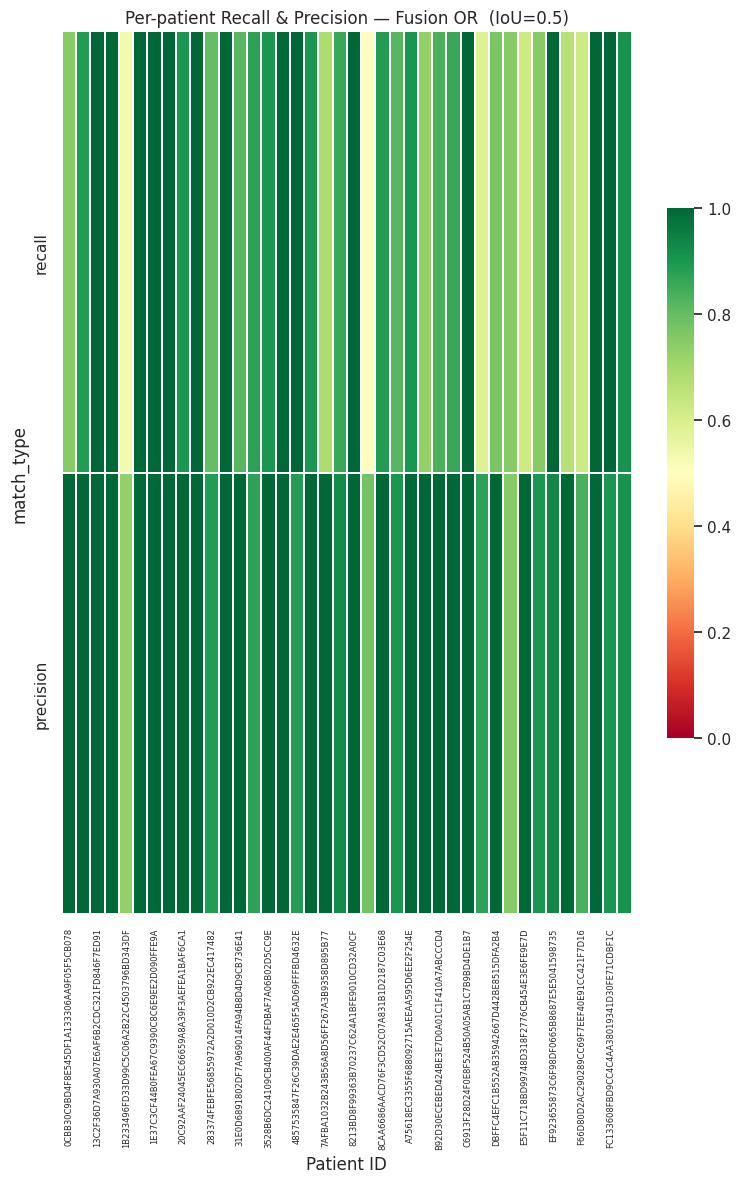

In [18]:
# ── Heatmap: recall per patient (OR strategy, top-40 patients by image count) ─
s = 'or'
df  = results_by_strategy_iou[s][IOU_ANALYSIS]
pat = patient_error_df(df)

# Pick patients with most images for readability
img_per_pat = df.groupby('patient_ID')['file_name'].nunique()
top_pats = img_per_pat.nlargest(40).index
pat_sub = pat.loc[pat.index.isin(top_pats), ['TP','FP','FN','recall','precision']]

fig, ax = plt.subplots(figsize=(8, max(4, len(pat_sub)*0.3)))
hm_data = pat_sub[['recall','precision']].T
sns.heatmap(hm_data, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, annot=False, cbar_kws={'shrink':0.6})
ax.set_title(f'Per-patient Recall & Precision — {strategy_labels[s]}  (IoU={IOU_ANALYSIS})')
ax.set_xlabel('Patient ID')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

---
## Section 7 — IoU Threshold Sensitivity

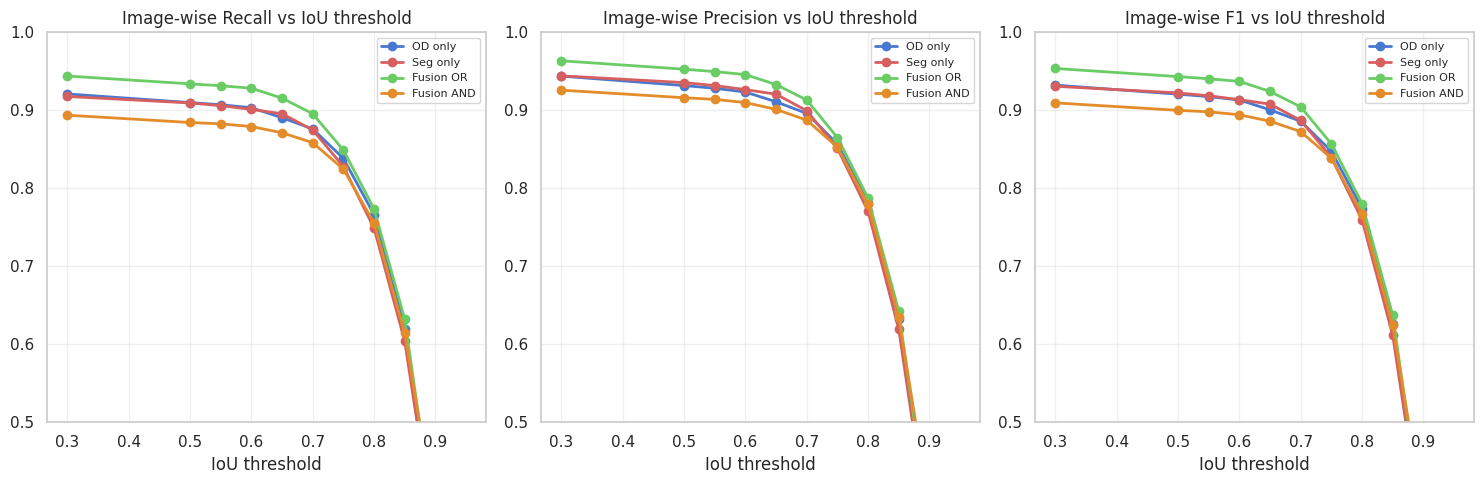

In [19]:
iou_list = sorted(results_by_strategy_iou[strategies[0]].keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_map = {'recall': 'img_recall', 'precision': 'img_precision', 'f1': 'img_f1'}

for ax, (metric, col) in zip(axes, metrics_map.items()):
    for s in strategies:
        vals = []
        for iou in iou_list:
            df = results_by_strategy_iou[s][iou]
            img_df = df[df['match_type'].isin(['TP','FP','FN'])].groupby(
                ['file_name','match_type']).size().unstack(fill_value=0)
            for c in ['TP','FP','FN']:
                if c not in img_df: img_df[c] = 0
            if metric == 'recall':
                vals.append((img_df['TP']/(img_df['TP']+img_df['FN']+1e-9)).mean())
            elif metric == 'precision':
                vals.append((img_df['TP']/(img_df['TP']+img_df['FP']+1e-9)).mean())
            else:
                r = (img_df['TP']/(img_df['TP']+img_df['FN']+1e-9)).mean()
                p = (img_df['TP']/(img_df['TP']+img_df['FP']+1e-9)).mean()
                vals.append(2*r*p/(r+p+1e-9))
        ax.plot(iou_list, vals, marker='o', color=COLORS[s],
                linewidth=2, label=strategy_labels[s])
    ax.set_title(f'Image-wise {metric.capitalize()} vs IoU threshold')
    ax.set_xlabel('IoU threshold')
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 8 — TP Box Quality (IoU & Center Distance)

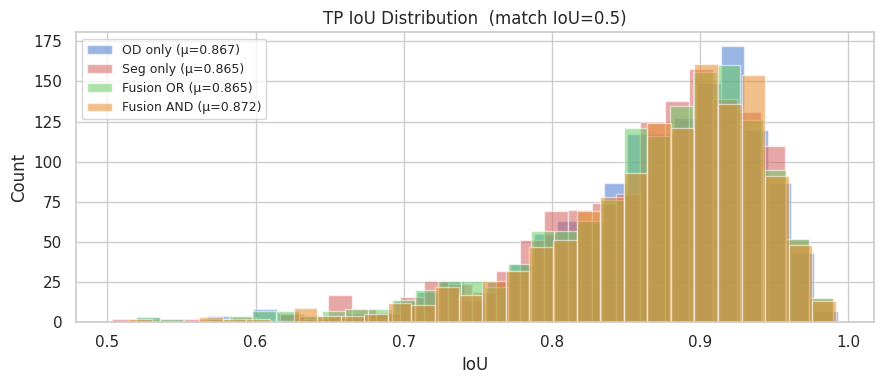

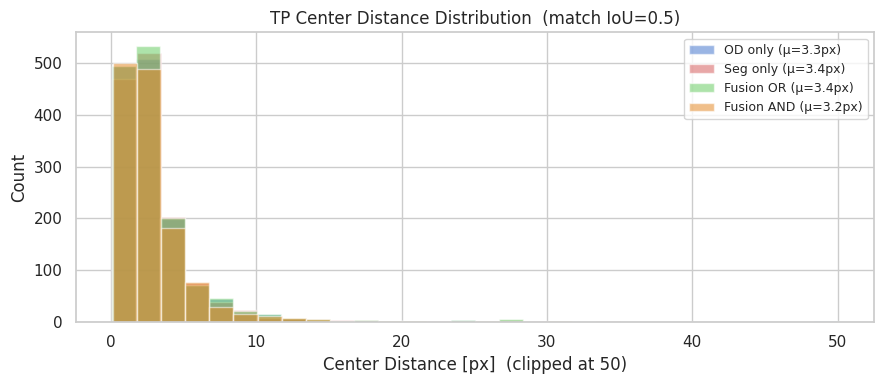

In [20]:
# ── 8a. TP IoU distribution per strategy ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for s in strategies:
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    iou_vals = df.loc[df['match_type']=='TP', 'iou'].dropna()
    ax.hist(iou_vals, bins=30, alpha=0.55, color=COLORS[s],
            label=f"{strategy_labels[s]} (μ={iou_vals.mean():.3f})")
ax.set_xlabel('IoU')
ax.set_ylabel('Count')
ax.set_title(f'TP IoU Distribution  (match IoU={IOU_ANALYSIS})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 8b. TP Center Distance distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for s in strategies:
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    cd = df.loc[df['match_type']=='TP', 'center_distance'].dropna()
    ax.hist(cd.clip(upper=50), bins=30, alpha=0.55, color=COLORS[s],
            label=f"{strategy_labels[s]} (μ={cd.mean():.1f}px)")
ax.set_xlabel('Center Distance [px]  (clipped at 50)')
ax.set_ylabel('Count')
ax.set_title(f'TP Center Distance Distribution  (match IoU={IOU_ANALYSIS})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

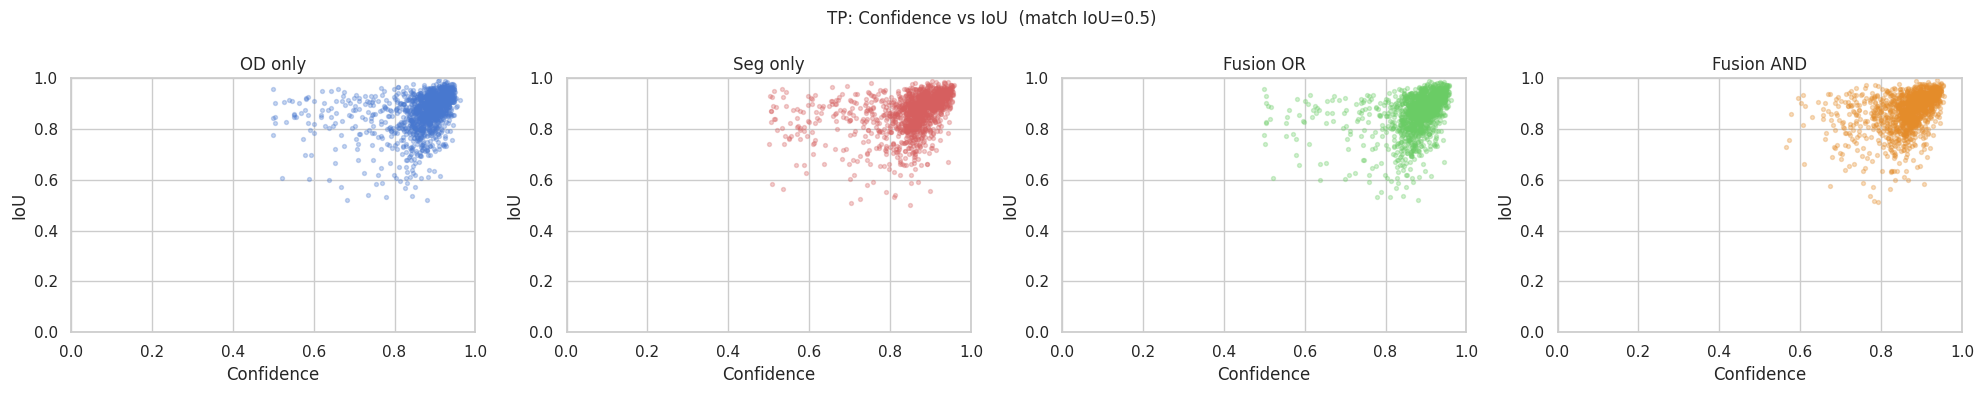

In [21]:
# ── 8c. Scatter: IoU vs conf for TP ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(strategies), figsize=(5*len(strategies), 4))
for ax, s in zip(axes, strategies):
    df = results_by_strategy_iou[s][IOU_ANALYSIS]
    tp = df[df['match_type']=='TP'].dropna(subset=['iou','conf'])
    ax.scatter(tp['conf'], tp['iou'], alpha=0.3, s=8, color=COLORS[s])
    ax.set_xlabel('Confidence')
    ax.set_ylabel('IoU')
    ax.set_title(strategy_labels[s])
    ax.set_xlim(0,1); ax.set_ylim(0,1)
fig.suptitle(f'TP: Confidence vs IoU  (match IoU={IOU_ANALYSIS})', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 9 — Error Visualization (Side-by-side)

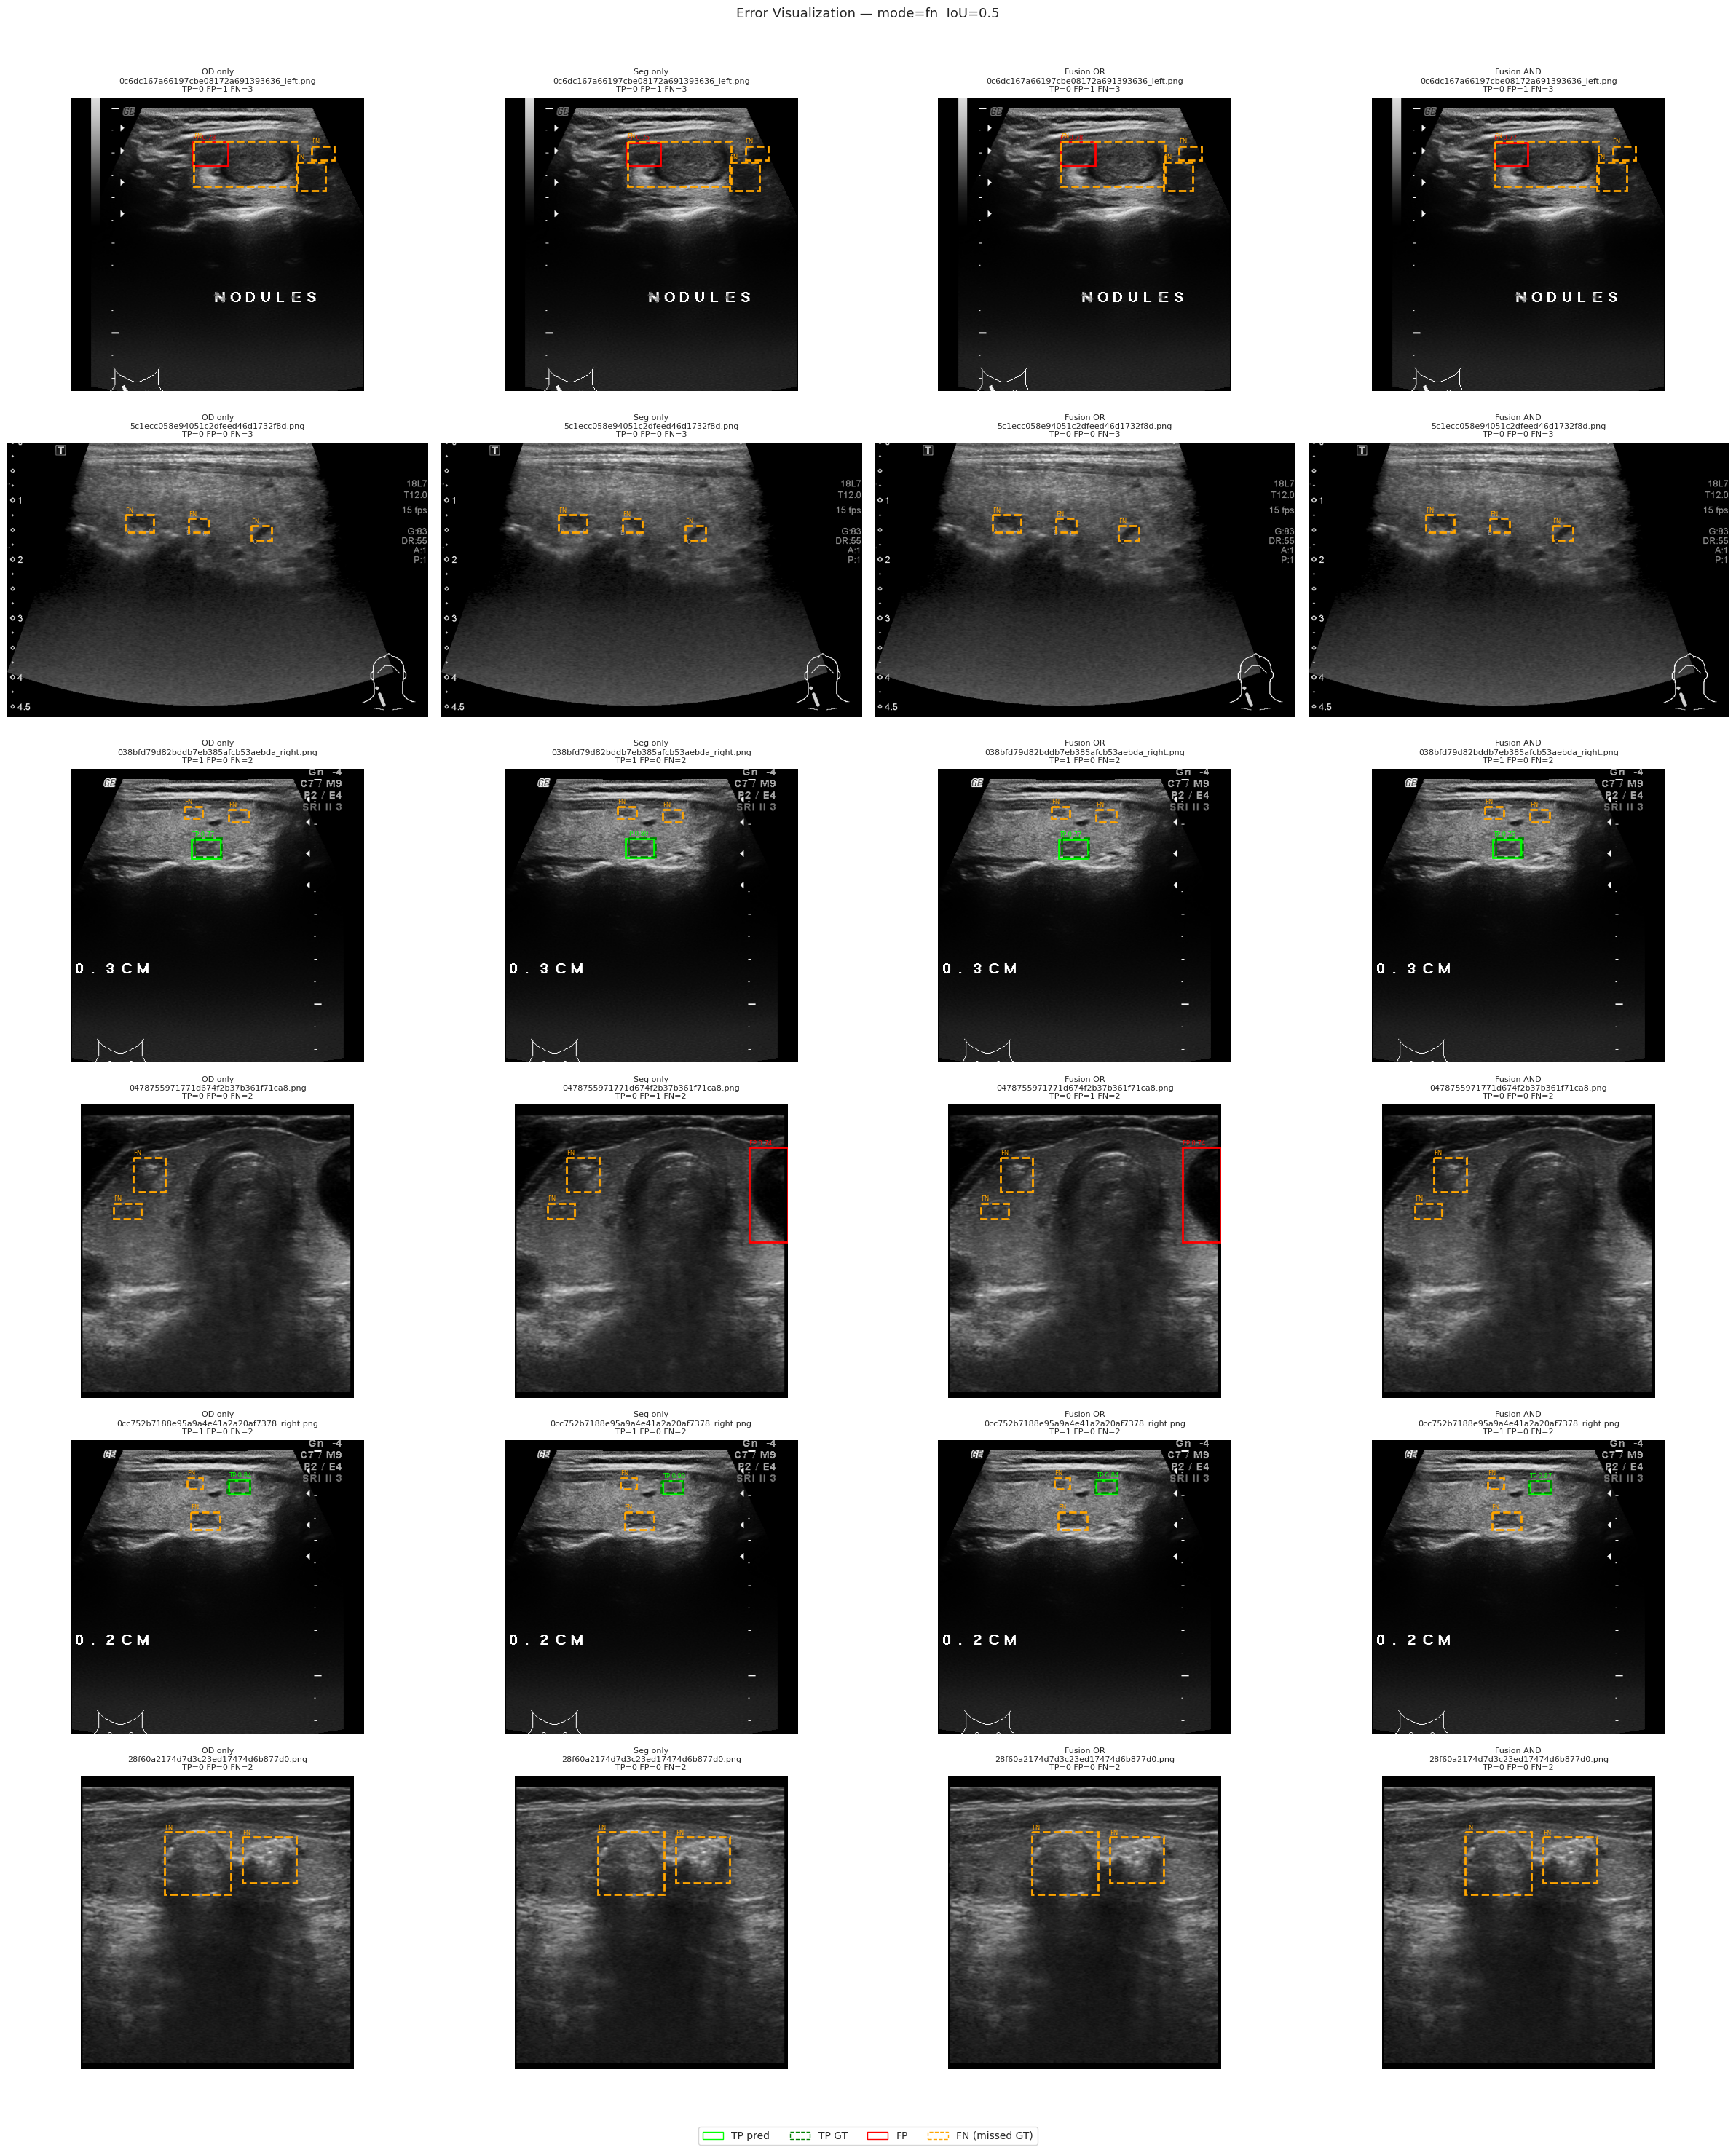

In [22]:
def draw_records_on_ax(ax, records_df):
    for _, rec in records_df.iterrows():
        mt = rec['match_type']
        if mt == 'TP':
            for box, c, ls in [(rec['pred_box'],'lime','-'),(rec['gt_box'],'green','--')]:
                if box is not None:
                    ax.add_patch(plt.Rectangle(
                        (box[0],box[1]), box[2]-box[0], box[3]-box[1],
                        linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
            if rec['pred_box'] is not None:
                ax.text(rec['pred_box'][0], rec['pred_box'][1]-4,
                        f"TP {rec['iou']:.2f}", color='lime', fontsize=6)
        elif mt == 'FP':
            b = rec['pred_box']
            if b is not None:
                ax.add_patch(plt.Rectangle(
                    (b[0],b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=2, edgecolor='red', facecolor='none'))
                ax.text(b[0], b[1]-4, f"FP {rec['conf']:.2f}", color='red', fontsize=6)
        elif mt == 'FN':
            b = rec['gt_box']
            if b is not None:
                ax.add_patch(plt.Rectangle(
                    (b[0],b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))
                ax.text(b[0], b[1]-4, 'FN', color='orange', fontsize=6)


def show_error_grid(od_raw, results_by_strategy_iou, iou_threshold,
                    mode='fn', strategy_focus='or', n=8, seed=42):
    """
    mode: 'fn' | 'fp' | 'worst'
    Shows 4 columns: OD only | Seg only | Fusion OR | Fusion AND
    """
    fused_df = results_by_strategy_iou[strategy_focus][iou_threshold]
    error_counts = (
        fused_df[fused_df['match_type'].isin(['FP','FN'])]
        .groupby(['file_name','match_type']).size().unstack(fill_value=0)
    )
    for c in ['FP','FN']:
        if c not in error_counts: error_counts[c] = 0

    if mode == 'fn':
        file_names = error_counts['FN'].nlargest(n).index.tolist()
    elif mode == 'fp':
        file_names = error_counts['FP'].nlargest(n).index.tolist()
    else:
        file_names = (error_counts['FP']+error_counts['FN']).nlargest(n).index.tolist()

    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}
    col_strategies = ['od_only','seg_only','or','and']
    col_titles     = ['OD only','Seg only','Fusion OR','Fusion AND']
    nrows, ncols   = len(file_names), len(col_strategies)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    if nrows == 1: axes = axes[np.newaxis, :]

    for ri, fname in enumerate(file_names):
        idx = fname_to_idx.get(fname)
        if idx is None: continue
        img = cv2.cvtColor(cv2.imread(od_raw[idx][0]), cv2.COLOR_BGR2RGB)
        for ci, (strat, title) in enumerate(zip(col_strategies, col_titles)):
            ax = axes[ri, ci]
            ax.imshow(img)
            sub = results_by_strategy_iou[strat][iou_threshold]
            draw_records_on_ax(ax, sub[sub['file_name']==fname])
            tp = (sub[sub['file_name']==fname]['match_type']=='TP').sum()
            fp = (sub[sub['file_name']==fname]['match_type']=='FP').sum()
            fn = (sub[sub['file_name']==fname]['match_type']=='FN').sum()
            ax.set_title(f"{title}\n{fname}\nTP={tp} FP={fp} FN={fn}", fontsize=8)
            ax.axis('off')

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP GT'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN (missed GT)'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f'Error Visualization — mode={mode}  IoU={iou_threshold}', fontsize=13)
    plt.tight_layout(rect=[0,0.03,1,0.97])
    plt.show()


# Show FN cases (images where fused OR misses most nodules)
show_error_grid(od_raw, results_by_strategy_iou,
                iou_threshold=IOU_ANALYSIS, mode='fn', n=6)

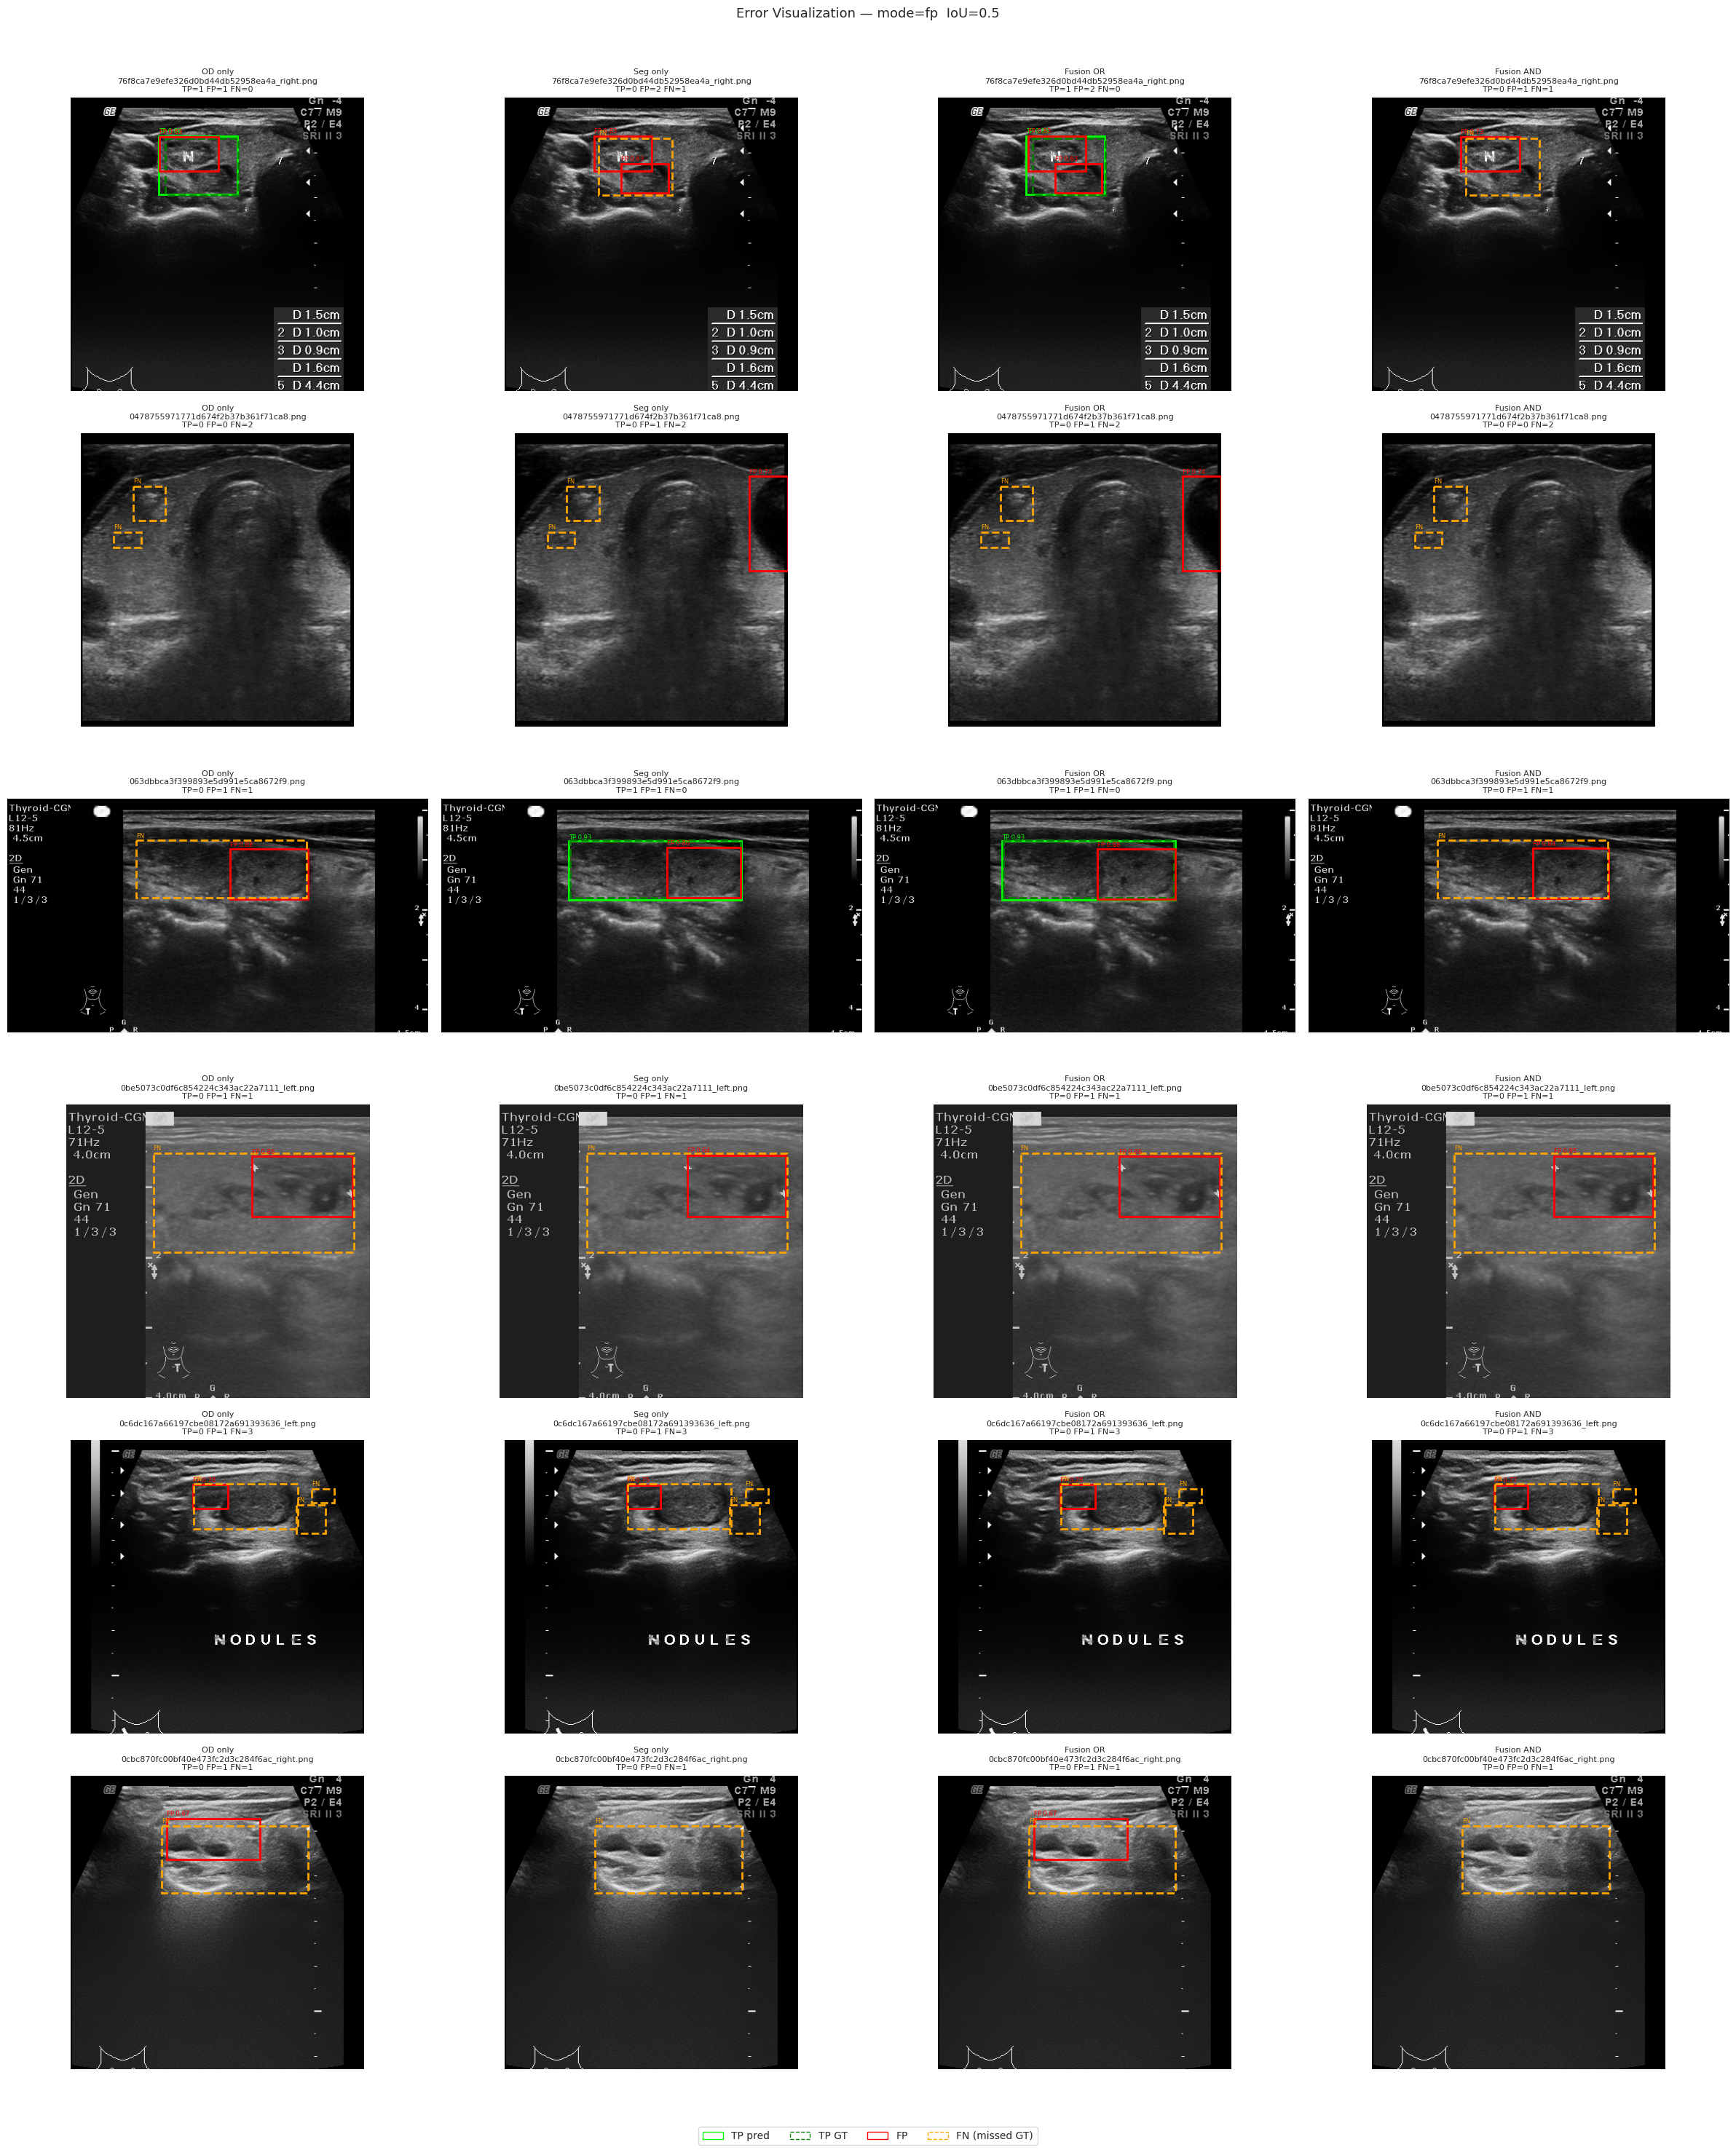

In [23]:
# Show FP cases (images with most false positives)
show_error_grid(od_raw, results_by_strategy_iou,
                iou_threshold=IOU_ANALYSIS, mode='fp', n=6)

### Section 9c — FN 圖片視覺化：Single Nodule vs Multi-Nodule

比較 single-nodule（label 只有 1 個結節）與 multi-nodule（≥2 個結節）的 FN 圖片，
確認 FN 多的圖片是否集中在 multi-nodule 案例。

FN 圖片總數      : 132
Single nodule FN : 43
Multi  nodule FN : 89


/tmp/ipykernel_2784/1452978909.py:95: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2784/1452978909.py:95: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/thyroid/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/thyroid/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


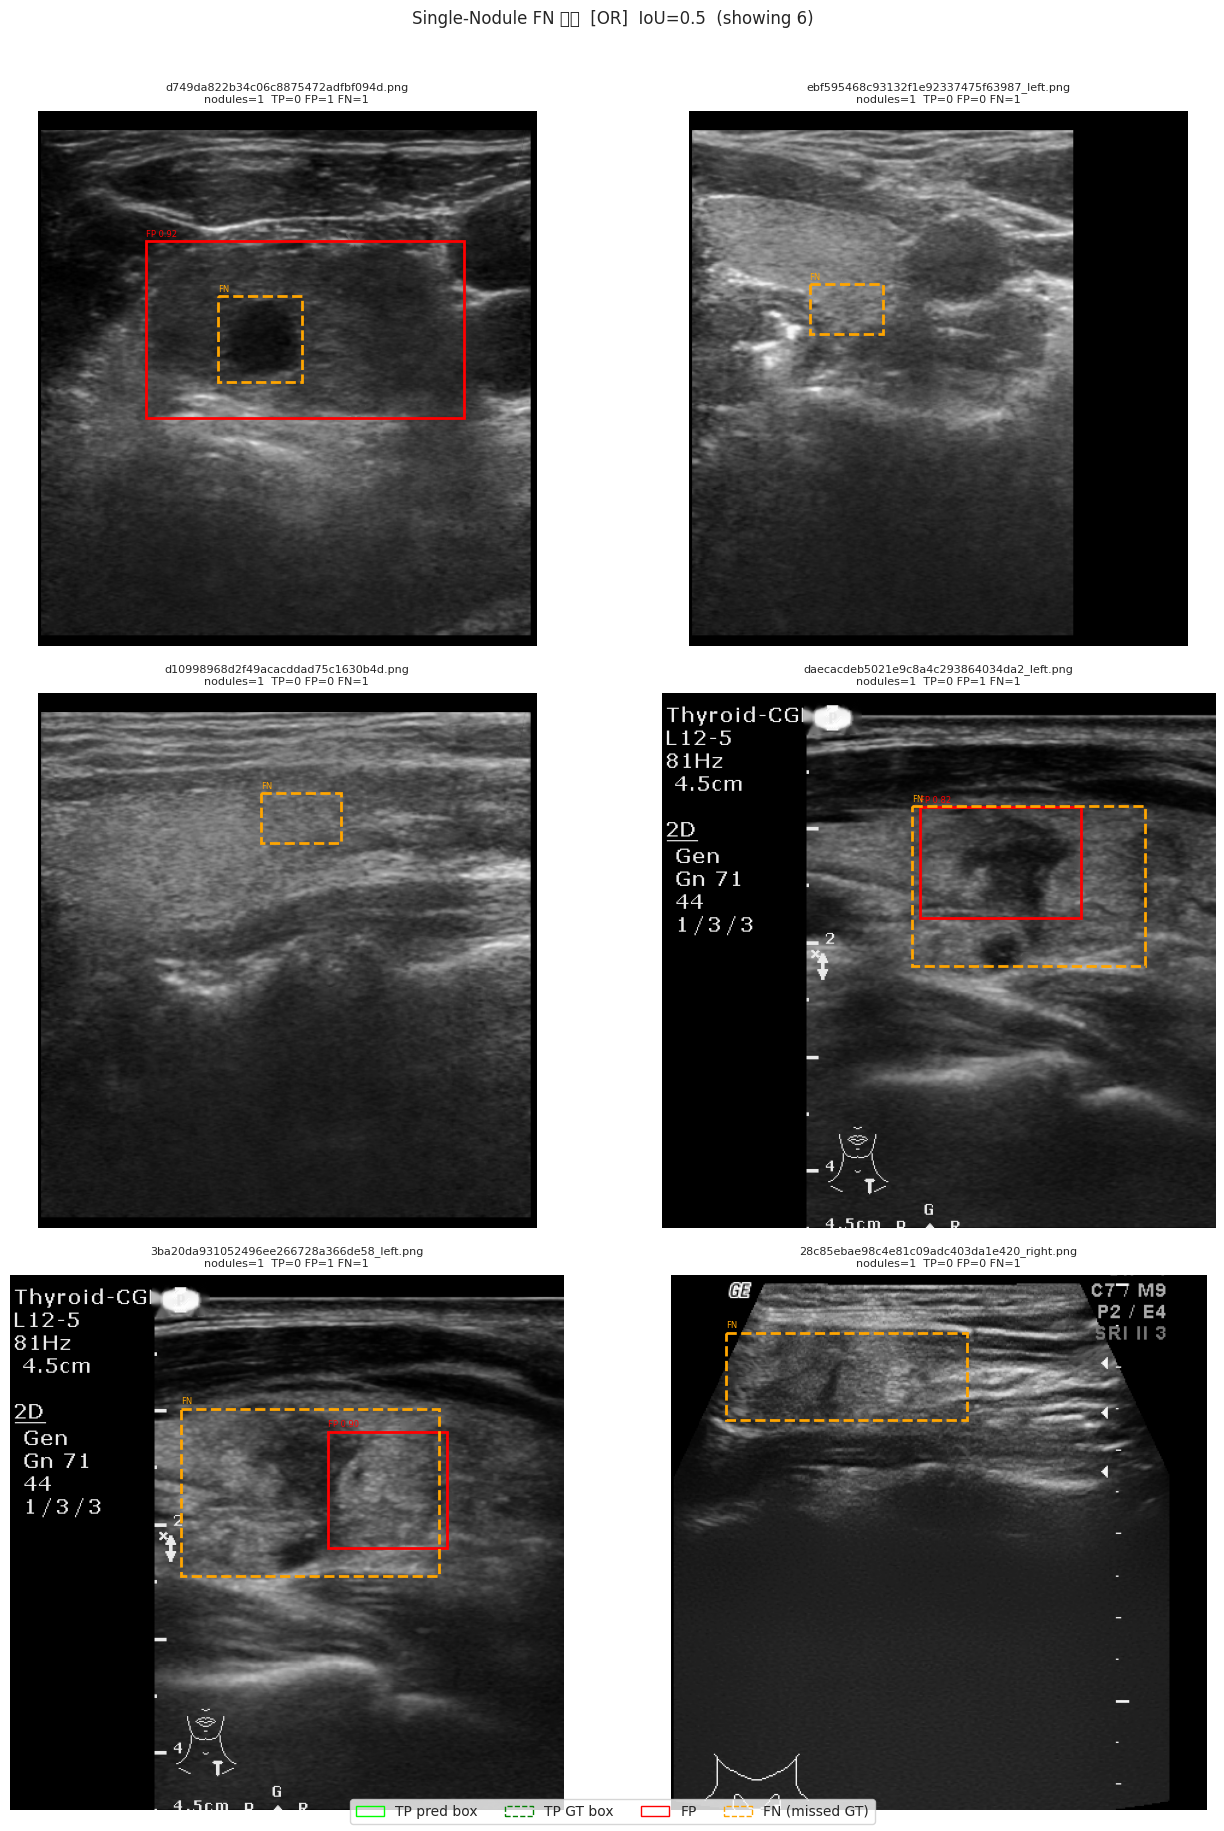

/tmp/ipykernel_2784/1452978909.py:95: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2784/1452978909.py:95: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/thyroid/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/thyroid/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


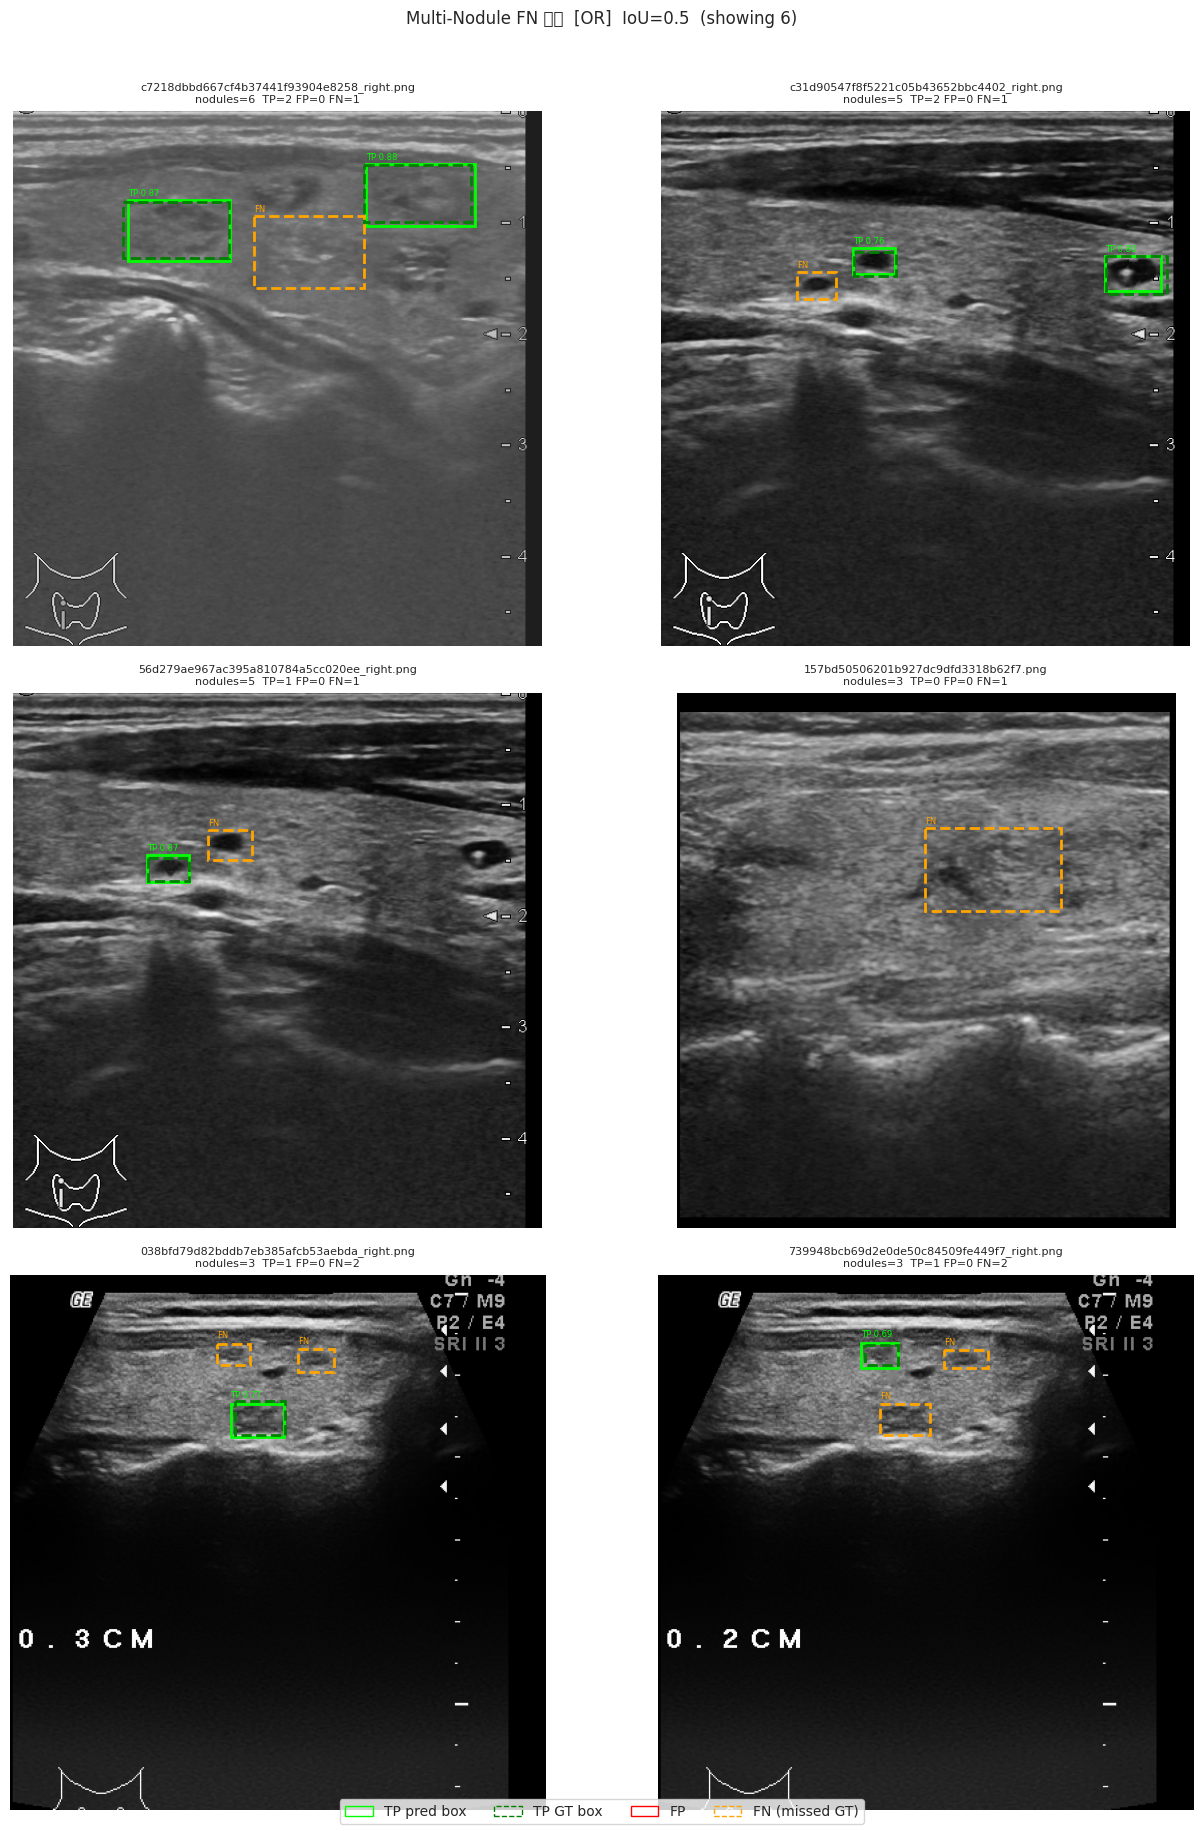

In [25]:
# ── 9c. FN 圖片：Single Nodule vs Multi-Nodule ────────────────────────────────
LABEL_DIR   = "/datadrive/yolo_data/all_data_nodule_normal_cut_od/labels"
VIZ_STRATEGY = 'or'        # 用 Fusion OR 作為主要分析 strategy
N_SHOW       = 6           # 每組顯示幾張

# ── Step 1: 計算每張圖的結節數（從 label 檔） ─────────────────────────────────
def count_nodules(fname):
    label_path = os.path.join(LABEL_DIR, fname.replace(".png", ".txt"))
    if not os.path.exists(label_path):
        return None
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    return len(lines)

fn_images = (
    results_by_strategy_iou[VIZ_STRATEGY][IOU_ANALYSIS]
    .query("match_type == 'FN'")
    ['file_name'].unique()
)

nodule_count_map = {f: count_nodules(f) for f in fn_images}

single_fn = sorted(
    [f for f, n in nodule_count_map.items() if n == 1],
    key=lambda f: nodule_count_map[f]
)
multi_fn = sorted(
    [f for f, n in nodule_count_map.items() if n is not None and n >= 2],
    key=lambda f: -nodule_count_map[f]   # 結節最多的排前面
)

print(f"FN 圖片總數      : {len(fn_images)}")
print(f"Single nodule FN : {len(single_fn)}")
print(f"Multi  nodule FN : {len(multi_fn)}")
if nodule_count_map:
    none_count = sum(1 for v in nodule_count_map.values() if v is None)
    if none_count:
        print(f"Label 未找到     : {none_count}")

# ── Step 2: 視覺化函式（依照傳入的 file list） ───────────────────────────────
fname_to_idx_od = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

def show_fn_grid(file_list, title_prefix, n=N_SHOW):
    """顯示 n 張圖，標出 FN（橘）/ TP（綠）/ FP（紅），使用 Fusion OR strategy。"""
    files = file_list[:n]
    if not files:
        print(f"{title_prefix}: 沒有圖片可顯示")
        return

    ncols = 2
    nrows = (len(files) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
    axes = np.array(axes).reshape(-1)  # 攤平

    sub_df = results_by_strategy_iou[VIZ_STRATEGY][IOU_ANALYSIS]

    for ax_i, fname in enumerate(files):
        ax = axes[ax_i]
        idx = fname_to_idx_od.get(fname)
        if idx is None:
            ax.set_visible(False)
            continue

        img = cv2.cvtColor(cv2.imread(od_raw[idx][0]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        recs = sub_df[sub_df['file_name'] == fname]
        draw_records_on_ax(ax, recs)

        tp = (recs['match_type'] == 'TP').sum()
        fp = (recs['match_type'] == 'FP').sum()
        fn_cnt = (recs['match_type'] == 'FN').sum()
        n_nodules = nodule_count_map.get(fname, '?')
        ax.set_title(
            f"{fname}\nnodules={n_nodules}  TP={tp} FP={fp} FN={fn_cnt}",
            fontsize=8
        )
        ax.axis('off')

    # 隱藏多餘的 axes
    for ax_i in range(len(files), len(axes)):
        axes[ax_i].set_visible(False)

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred box'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP GT box'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN (missed GT)'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(
        f"{title_prefix}  [{VIZ_STRATEGY.upper()}]  IoU={IOU_ANALYSIS}  (showing {len(files)})",
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

# ── Step 3: 分別視覺化 ────────────────────────────────────────────────────────
show_fn_grid(single_fn, "Single-Nodule FN 圖片", n=N_SHOW)
show_fn_grid(multi_fn,  "Multi-Nodule FN 圖片",  n=N_SHOW)

---
## Section 10 — Export Error Report CSV

In [24]:
# Export per-image error counts across all strategies and IoU thresholds
export_rows = []
for s in strategies:
    for iou in [0.3, 0.5, 0.7]:
        df = results_by_strategy_iou[s][iou]
        g  = df.groupby('file_name')['match_type'].value_counts().unstack(fill_value=0)
        for c in ['TP','FP','FN','TN']:
            if c not in g: g[c] = 0
        g = g.reset_index()
        g['strategy']      = s
        g['iou_threshold'] = iou
        g['patient_ID']    = g['file_name'].map(
            dict(zip(df['file_name'], df['patient_ID'])))
        export_rows.append(g)

error_report_df = pd.concat(export_rows, ignore_index=True)
error_report_df['recall']    = error_report_df['TP'] / \
    (error_report_df['TP'] + error_report_df['FN'] + 1e-9)
error_report_df['precision'] = error_report_df['TP'] / \
    (error_report_df['TP'] + error_report_df['FP'] + 1e-9)

out_dir = f'{data_root}/yolo_output/ensemble_{od_name}__{seg_name}'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'error_report_per_image.csv')
error_report_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({len(error_report_df)} rows)')
display(error_report_df.head(10))

Saved: /datadrive/yolo_output/ensemble_2026_03_11(1)__2026_03_12(1)/error_report_per_image.csv  (17328 rows)


match_type,file_name,FN,FP,TN,TP,strategy,iou_threshold,patient_ID,recall,precision
0,0033a19c56c98917ef5e42393de82db1_right.png,0,0,0,1,od_only,0.3,E472BF63383BB747EA6BB3371336105A9CB34B3D,1.0,1.0
1,006a1cfbff4f73fb4f7f9a94c0c8696d.png,0,0,0,1,od_only,0.3,50D832B1FCA45BE86CA65AF070117FC80B5CA4C8,1.0,1.0
2,008d86950446532d11cb9e3b1c6fcea3_left.png,0,0,0,1,od_only,0.3,21FC027A51AF167A34E7AD58DF886EB437217FCA,1.0,1.0
3,008d86950446532d11cb9e3b1c6fcea3_right.png,0,0,0,1,od_only,0.3,21FC027A51AF167A34E7AD58DF886EB437217FCA,1.0,1.0
4,00f2ac55aaeb8e611835bb7897487cc5_left.png,0,0,0,1,od_only,0.3,5420105E55A21BB54456F9727BEE2FA0520457C1,1.0,1.0
5,00f2ac55aaeb8e611835bb7897487cc5_right.png,0,0,0,1,od_only,0.3,5420105E55A21BB54456F9727BEE2FA0520457C1,1.0,1.0
6,00f6c95b6c738d86044b8b27b5c660ff.png,1,0,0,0,od_only,0.3,F66D80D2AC290289CC69F7EEF40E91CC421F7D16,0.0,0.0
7,010f527a2cdf61de050f0fc9446c44bc_left.png,0,0,0,1,od_only,0.3,E5F11C718BD99748D318F2776CB454E3E6FE9E7D,1.0,1.0
8,010f527a2cdf61de050f0fc9446c44bc_right.png,0,0,0,1,od_only,0.3,E5F11C718BD99748D318F2776CB454E3E6FE9E7D,1.0,1.0
9,018862191d1085555725a6a9a02e7878.png,0,0,0,1,od_only,0.3,0E2C63DD8749BC2A49AE295CDF22837FC822A686,1.0,1.0


In [5]:
!ls /

Applications Users        cores        home         sbin         var
Library      Volumes      dev          opt          tmp
System       bin          etc          private      usr


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

REPORT_CSV = "/datadrive/yolo_output/ensemble_2026_03_11(1)_2026_03_12(1)/error_report_per_image.csv"
LABEL_DIR  = "/datadrive/yolo_data/all_data_nodule_normal_cut_od/labels"

df = pd.read_csv(REPORT_CSV)

# 取每張圖的最大 FN（跨 strategy 去重）
high_fn = (
    df[df["FN"] >= 1]
    .groupby("file_name", as_index=False)
    .agg(FN=("FN", "max"), TP=("TP", "max"))
    .sort_values("FN", ascending=False)
)

# 從 label 檔計算每張圖的結節數
def count_nodules(fname):
    label_path = os.path.join(LABEL_DIR, fname.replace(".png", ".txt"))
    if not os.path.exists(label_path):
        return None
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    return len(lines)

high_fn["nodule_count"] = high_fn["file_name"].map(count_nodules)
high_fn = high_fn.dropna(subset=["nodule_count"]).astype({"nodule_count": int})

# ── 表格：FN × nodule_count ──────────────────────────────────────────────
pivot = high_fn.groupby(["FN", "nodule_count"]).size().reset_index(name="image_count")
print("FN 與結節數量交叉表：")
print(pivot.to_string(index=False))

# ── 相關性 ───────────────────────────────────────────────────────────────
corr = high_fn[["FN", "nodule_count"]].corr().loc["FN", "nodule_count"]
print(f"\nFN 與 nodule_count Pearson 相關係數：{corr:.3f}")

# ── 視覺化 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：heatmap
pivot_table = pivot.pivot(index="FN", columns="nodule_count", values="image_count").fillna(0)
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("FN × 結節數量 (image count)")
axes[0].set_xlabel("結節數量 (nodule_count)")
axes[0].set_ylabel("FN 數")

# 右：grouped bar
pivot.plot(
    kind="bar", x="nodule_count", y="image_count",
    color=[plt.cm.tab10(i) for i in pivot["FN"].astype("category").cat.codes],
    ax=axes[1], legend=False
)
# 用不同顏色標 FN 分組
for fn_val, group in pivot.groupby("FN"):
    axes[1].bar(
        group["nodule_count"].astype(str),
        group["image_count"],
        label=f"FN={int(fn_val)}"
    )
axes[1].cla()

for fn_val, group in pivot.groupby("FN"):
    axes[1].bar(
        [str(int(n)) for n in group["nodule_count"]],
        group["image_count"],
        label=f"FN={int(fn_val)}",
        alpha=0.8
    )
axes[1].set_title("結節數量 vs FN（分組長條圖）")
axes[1].set_xlabel("結節數量 (nodule_count)")
axes[1].set_ylabel("圖片數")
axes[1].legend(title="FN")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/datadrive/yolo_output/ensemble_2026_03_11(1)_2026_03_12(1)/error_report_per_image.csv'